In [1]:
# from data_synthesizer.util import  plot_training_loss, ModelType
from typing import Tuple
import pandas as pd
import pickle

from data_loader import DataLoader
from data_synthesizer.sdv import SDVCTGAN_, SDVTVAE_
from data_evaluator import ClassifierType
from data_synthesizer.pipeline import PipelineBuilder, PipelineResults, load_all_results
from data_synthesizer.privacy_sampling import get_epsilon

from evaluation_report.ressemblance_report import ResemblanceReport
from evaluation_report.utility_report import UtilityReport
from evaluation_report.privacy_report import PrivacyReport 
from evaluation_report.privacy_anonymeter_report import PrivacyAnonymeterReport


In [2]:
import sys
from pathlib import Path

# Add repo root so `import experiments` works in notebooks.
sys.path.append(str(Path.cwd().parent.parent))

from experiments.paths import RESULTS_DIR, DATA_DIR, BASELINE_DIR, UTILITY_ONLY_DIR


## Loading Data

In [3]:
cat_list_credit_card = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6', 'default.payment.next.month']
num_list_credit_card = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4','BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3','PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
credit_qai_columns = ['LIMIT_BAL','SEX','EDUCATION','MARRIAGE','AGE']
credit_risk_column = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6','default.payment.next.month']

df_real_credit_card_train = DataLoader(f'{DATA_DIR}/credit_card_Train.csv').get_dataframe(cat_list_credit_card,  drop_identation=True)
df_real_credit_card_test = DataLoader(f'{DATA_DIR}/credit_card_Test.csv').get_dataframe(cat_list_credit_card,  drop_identation=True)
credit_real_dict ={'data' : df_real_credit_card_train, 'cat_list' : cat_list_credit_card, 'num_list' : num_list_credit_card}


In [4]:
cat_list_adult = ['workclass','education','marital-status','occupation','relationship','race','sex','native-country','income']
num_list_adult = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']
adult_qai_columns = ['education','education-num','marital-status','occupation','relationship','sex', 'native-country']
adult_risk_column = ['capital-gain','capital-loss','hours-per-week','income', 'race']
df_real_adult_train = DataLoader(f'{DATA_DIR}/adult_train.csv').get_dataframe(cat_list_adult)
df_real_adult_test = DataLoader(f'{DATA_DIR}/adult_test.csv').get_dataframe(cat_list_adult)


In [5]:
num_list_cardio = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
cat_list_cardio = ['gender','cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

cardio_qai_columns = ['age','gender','height','weight']
cardio_risk_column = ['ap_lo','ap_hi','cholesterol','gluc','smoke','alco','active','cardio']

df_real_cardio_train = DataLoader(f'{DATA_DIR}/cardio_train.csv').get_dataframe(cat_list_cardio, sep = ',')
df_real_cardio_test = DataLoader(f'{DATA_DIR}/cardio_test.csv').get_dataframe(cat_list_cardio, sep = ',')


In [6]:
credit_ctgan  = load_all_results(f'{BASELINE_DIR}/credit_ctgan_baseline')
credit_tvae  = load_all_results(f'{BASELINE_DIR}/credit_tvae_baseline')


dict_results_credit = {
    'credit CTGAN' : credit_ctgan,
    'credit TVAE' : credit_tvae}



In [7]:
adult_ctgan  = load_all_results(f'{BASELINE_DIR}/adult_ctgan_baseline')
adult_tvae  = load_all_results(f'{BASELINE_DIR}/adult_tvae_baseline')

dict_results_adult  = {
    'adult CTGAN' : adult_ctgan,
    'adult TVAE' : adult_tvae}

In [8]:
cardio_ctgan = load_all_results(f'{BASELINE_DIR}/cardio_ctgan_baseline')
cardio_tvae = load_all_results(f'{BASELINE_DIR}/cardio_tvae_baseline')

dict_results_cardio = {
    'cardio CTGAN' : cardio_ctgan,
    'cardio TVAE' : cardio_tvae}


In [24]:
credit_resemblance_report = ResemblanceReport(df_real_credit_card_train, cat_list_credit_card, num_list_credit_card, dict_results_credit)
credit_utility_report = UtilityReport(df_real_credit_card_train, cat_list_credit_card, num_list_credit_card, dict_results_credit)
credit_privacy_report = PrivacyReport(df_real_credit_card_train, cat_list_credit_card, num_list_credit_card, dict_results_credit)
credit_privacy_anonymeter_report = PrivacyAnonymeterReport(df_real_credit_card_train, cat_list_credit_card, num_list_credit_card, dict_results_credit)

adult_resemblance_report = ResemblanceReport(df_real_adult_train, cat_list_adult, num_list_adult, dict_results_adult)
adult_utility_report = UtilityReport(df_real_adult_train, cat_list_adult, num_list_adult, dict_results_adult)
adult_privacy_report = PrivacyReport(df_real_adult_train, cat_list_adult, num_list_adult, dict_results_adult)
adult_privacy_anonymeter_report = PrivacyAnonymeterReport(df_real_adult_train, cat_list_adult, num_list_adult, dict_results_adult)

cardio_resemblance_report = ResemblanceReport(df_real_cardio_train, cat_list_cardio, num_list_cardio, dict_results_cardio)
cardio_utility_report = UtilityReport(df_real_cardio_train, cat_list_cardio, num_list_cardio, dict_results_cardio)
cardio_privacy_report = PrivacyReport(df_real_cardio_train, cat_list_cardio, num_list_cardio, dict_results_cardio)
cardio_privacy_anonymeter_report = PrivacyAnonymeterReport(df_real_cardio_train, cat_list_cardio, num_list_cardio, dict_results_cardio)


In [9]:
def get_mode_collapse(real, synth, categorical_columns) :
    mode_collapse_dict = {}
    for c in categorical_columns :
        observed = pd.crosstab(real[c], synth[c], dropna=False)
        
        not_mode_collapse = set(synth[c].unique()) == set(real[c].unique())
        if  not not_mode_collapse :
            cats = pd.Categorical(synth[c], categories=real[c].unique())
            cat_freq = cats.value_counts()
            cat_freq[cat_freq == 0].index.to_list()
            mode_collapse_dict[c] = cat_freq[cat_freq == 0].index.to_list()
    return mode_collapse_dict

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_per_feature_heatmap(
    metric_series_dict,
    metric_name="Cohen's d",
    dataset_name=None,
    sort_features=True,
    figsize=None,
    ax=None,
    vmin=None,
    vmax=None,
):
    # Build a DataFrame: rows = features, columns = models
    df = pd.DataFrame(metric_series_dict)

    if sort_features:
        df = df.loc[df.max(axis=1).sort_values(ascending=False).index]

    n_features, n_models = df.shape

    # Create fig/ax only if not provided
    created_fig = False
    if ax is None:
        if figsize is None:
            width = max(4, 1.2 * n_models)
            height = max(4, 0.4 * n_features)
            figsize = (width, height)
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True
    else:
        fig = ax.figure

    im = ax.imshow(df.values, aspect="auto", vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(n_models))
    ax.set_xticklabels(df.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(n_features))
    ax.set_yticklabels(df.index)

    ax.set_xlabel("Model")
    ax.set_ylabel("Feature")

    if dataset_name is not None:
        title = f"{dataset_name} — {metric_name} per feature"
    else:
        title = f"{metric_name} per feature"
    ax.set_title(title)

    # Only tighten if we own the figure
    if created_fig:
        fig.tight_layout()

    return fig, ax, im


def plot_per_feature_heatmap_multi(
    all_metrics_dict,
    metric_name="JS divergence",
    sort_features=True,
    figsize=None,
    datasets_order=None,
):
    # --- Group keys "<dataset> <model>" ---
    grouped = {}
    for key, series in all_metrics_dict.items():
        dataset, model = key.split(maxsplit=1)
        grouped.setdefault(dataset, {})[model] = series

    if datasets_order is None:
        datasets = sorted(grouped.keys())
    else:
        datasets = datasets_order

    n_datasets = len(datasets)

    # --- Shared color scale ---
    all_values = np.concatenate([s.values for s in all_metrics_dict.values()])
    vmin, vmax = all_values.min(), all_values.max()

    # --- Figure & subplots ---
    if figsize is None:
        figsize = (10, 4 * n_datasets)

    fig, axes = plt.subplots(n_datasets, 1, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    ims = []

    for ax, dataset in zip(axes, datasets):
        metric_series_dict = grouped[dataset]
        dataset_title = dataset.capitalize()

        fig, ax, im = plot_per_feature_heatmap(
            metric_series_dict=metric_series_dict,
            metric_name=metric_name,
            dataset_name=dataset_title,
            sort_features=sort_features,
            ax=ax,
            vmin=vmin,
            vmax=vmax,
        )
        ims.append(im)

    # --- Leave room on the right for colorbar ---
    # everything left of x=0.88 is for subplots
    fig.tight_layout(rect=[0.0, 0.0, 0.88, 1.0])

    # --- Explicit colorbar axes OUTSIDE the plots ---
    cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    cbar = fig.colorbar(ims[-1], cax=cbar_ax)
    cbar.set_label(metric_name)

    return fig, axes


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_per_feature_bar(
    metric_series_dict,
    metric_name="Cohen's d",
    dataset_name=None,
    sort_features=True,
    figsize=None,
    ax=None,
    ylim=None,
):
    """
    metric_series_dict: dict like {"CTGAN": Series, "TVAE": Series}
                        Series index = features, values = metric
    """

    # Build DataFrame: rows = features, cols = models
    df = pd.DataFrame(metric_series_dict).dropna(how="all")

    if sort_features:
        # Sort by max metric across models (descending)
        df = df.loc[df.max(axis=1).sort_values(ascending=False).index]

    n_features, n_models = df.shape
    models = list(df.columns)

    # Create fig/ax only if not provided
    created_fig = False
    if ax is None:
        if figsize is None:
            # Wider when many features
            width = max(6, 0.6 * n_features)
            height = 4
            figsize = (width, height)
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True
    else:
        fig = ax.figure

    x = np.arange(n_features)
    total_width = 0.8
    bar_width = total_width / n_models

    # Center grouped bars on x-ticks
    offsets = (np.arange(n_models) - (n_models - 1) / 2.0) * bar_width

    for i, model in enumerate(models):
        ax.bar(x + offsets[i], df[model].values, width=bar_width, label=model)

    ax.set_xticks(x)
    ax.set_xticklabels(df.index, rotation=45, ha="right")

    ax.set_xlabel("Feature")
    ax.set_ylabel(metric_name)

    if dataset_name is not None:
        title = f"{dataset_name} — {metric_name} per feature"
    else:
        title = f"{metric_name} per feature"
    ax.set_title(title)

    ax.legend(title="Model")

    if ylim is not None:
        ax.set_ylim(ylim)

    if created_fig:
        fig.tight_layout()

    return fig, ax


In [12]:
def plot_per_feature_bar_multi(
    all_metrics_dict,
    metric_name="JS distance",
    sort_features=True,
    figsize=None,
    datasets_order=None,
    sharey=True,
):
    """
    all_metrics_dict: dict with keys "<dataset> <model>", e.g. "credit CTGAN"
                      values are Series(feature -> metric)
    """

    # Group keys "<dataset> <model>"
    grouped = {}
    for key, series in all_metrics_dict.items():
        dataset, model = key.split(maxsplit=1)
        grouped.setdefault(dataset, {})[model] = series

    if datasets_order is None:
        datasets = sorted(grouped.keys())
    else:
        datasets = datasets_order

    n_datasets = len(datasets)

    # Shared y-range across all subplots
    all_values = np.concatenate([s.dropna().values for s in all_metrics_dict.values()])
    y_min = min(0, all_values.min())
    y_max = all_values.max() * 1.05
    ylim = (y_min, y_max) if sharey else None

    if figsize is None:
        figsize = (10, 3 * n_datasets)

    fig, axes = plt.subplots(
        n_datasets,
        1,
        figsize=figsize,
        squeeze=False,
        sharey=sharey,
    )
    axes = axes.ravel()

    for ax, dataset in zip(axes, datasets):
        metric_series_dict = grouped[dataset]
        dataset_title = dataset.capitalize()
        plot_per_feature_bar(
            metric_series_dict=metric_series_dict,
            metric_name=metric_name,
            dataset_name=dataset_title,
            sort_features=sort_features,
            ax=ax,
            ylim=ylim,
        )

    fig.tight_layout()
    return fig, axes


In [13]:

def get_cohen_result(evaluation_results):
    cohen = {}
    for key, result in evaluation_results.items() :
        cohen[key] = result['resemblance_evaluation_results']['numerical_univariate']['univariate_num_js']['cohen_s_d']
    return cohen

In [14]:
def get_jsdivergence_result(evaluation_results) :
    js = {}
    for key, result in evaluation_results.items() :
        js[key] = result['resemblance_evaluation_results']['categorical_univariate']['jensen_shanon']['JS_divergence']
    return js


In [15]:
def get_anonymeter_result(evaluation_results) :
    anonym = {}
    for key, result in evaluation_results.items() :
        anonym[key] = result['privacy_anonymeter_results']
    return anonym

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def plot_matrix_triplet(real_df, synth_df, title_prefix, vmax=None):
    """
    real_df, synth_df: pandas DataFrames with same index/columns
    title_prefix: e.g. "Credit CTGAN – Corr. Ratio"
    vmax: optional, for consistent color scale across models
    """
    diff_df = (synth_df - real_df).abs()

    if vmax is None:
        vmax = np.max([real_df.values.max(), synth_df.values.max(), diff_df.values.max()])

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for ax, data, title in zip(
        axes,
        [real_df, synth_df, diff_df],
        ["Real", "Synthetic", "|Synthetic − Real|"]
    ):
        im = ax.imshow(data.values, vmin=0, vmax=vmax)
        ax.set_xticks(range(data.shape[1]))
        ax.set_yticks(range(data.shape[0]))
        ax.set_xticklabels(data.columns, rotation=90)
        ax.set_yticklabels(data.index)
        ax.set_title(title)
    
    fig.suptitle(title_prefix, y=1.05)
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
    fig.tight_layout()
    plt.show()


In [17]:
import pandas as pd
from collections.abc import Mapping

def _extract_scalar(d, key):
    """Handle both {'corr': value} and plain float cases."""
    val = d[key]
    if isinstance(val, Mapping):
        # e.g. {'corr': 0.9369}
        return val.get("corr", list(val.values())[0])
    return val

def build_summary_df(corr_ratio_results, pearson_results, cramer_results):
    rows = []

    all_keys = sorted(corr_ratio_results.keys())  # e.g. "adult CTGAN"

    for name in all_keys:
        dataset, model = name.split()  # assumes "credit CTGAN" format

        corr_res    = corr_ratio_results[name]
        pearson_res = pearson_results[name]
        cramer_res  = cramer_results[name]

        rows.append({
            "dataset": dataset,
            "model": model,   # CTGAN / TVAE

            # corr-ratio
            "diff_norm_corr_ratio": corr_res["diff_norm_corr_ratio"],
            "corr_ratio_spearman": _extract_scalar(
                corr_res, "corr_ratio_spearman_correlation_coefficient"
            ),

            # pearson
            "pearson_norm_diff": pearson_res["pearson_norm_diff"],
            "pearson_spearman": pearson_res["pearson_spearman_correlation_coefficient"],

            # cramer
            "diff_norm_cramer": cramer_res["diff_norm_cramer"],
            "cramer_spearman": cramer_res["cramer_spearman_correlation_coefficient"],
        })

    return pd.DataFrame(rows)




In [18]:
import numpy as np
import matplotlib.pyplot as plt

def plot_grouped_bar(summary_df, metric_col, ylabel=None, title=None):
    """
    summary_df: has columns ['dataset', 'model', metric_col]
    metric_col: e.g. 'diff_norm_corr_ratio'
    """
    datasets = summary_df["dataset"].unique()
    models   = summary_df["model"].unique()  # ['CTGAN', 'TVAE']

    x = np.arange(len(datasets))
    width = 0.35

    fig, ax = plt.subplots(figsize=(6, 4))

    for i, model in enumerate(models):
        vals = []
        for ds in datasets:
            val = summary_df[
                (summary_df["dataset"] == ds) & (summary_df["model"] == model)
            ][metric_col].values[0]
            vals.append(val)

        ax.bar(x + (i - 0.5)*width, vals, width, label=model)

    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.set_ylabel(ylabel if ylabel else metric_col)
    if title:
        ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.show()


In [19]:
import numpy as np
import matplotlib.pyplot as plt

def plot_matrix_errors_vs_rankcorr(summary_df):
    
    # (metric_col, ylabel, title)
    left_metrics = [
        ("diff_norm_corr_ratio",  "‖corr_ratio_real − corr_ratio_synth‖",      "Corr-ratio matrix error (lower is better)"),
        ("pearson_norm_diff",     "‖Pearson_real − Pearson_synth‖",            "Pearson matrix error (lower is better)"),
        ("diff_norm_cramer",      "‖Cramér_real − Cramér_synth‖",              "Cramér's V matrix error (lower is better)")
    ]

    right_metrics = [
        ("corr_ratio_spearman",   "Spearman(corr_ratio_real, corr_ratio_synth)", "Corr-ratio rank correlation (higher is better)"),
        ("pearson_spearman",      "Spearman(Pearson_real, Pearson_synth)",       "Pearson rank correlation (higher is better)"),
        ("cramer_spearman",       "Spearman(Cramér_real, Cramér_synth)",         "Cramér's V rank correlation (higher is better)")
    ]

    datasets = summary_df["dataset"].unique()
    models   = summary_df["model"].unique()
    x = np.arange(len(datasets))
    width = 0.35

    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    
    # Left column = matrix errors
    for ax, (metric_col, ylabel, title) in zip(axes[:, 0], left_metrics):
        for i, model in enumerate(models):
            vals = [
                summary_df[(summary_df.dataset == ds) & (summary_df.model == model)][metric_col].values[0]
                for ds in datasets
            ]
            ax.bar(x + (i - 0.5) * width, vals, width, label=model)

        ax.set_xticks(x)
        ax.set_xticklabels(datasets)
        ax.set_ylabel(ylabel)
        ax.set_title(title)

    # Right column = rank correlations
    for ax, (metric_col, ylabel, title) in zip(axes[:, 1], right_metrics):
        for i, model in enumerate(models):
            vals = [
                summary_df[(summary_df.dataset == ds) & (summary_df.model == model)][metric_col].values[0]
                for ds in datasets
            ]
            ax.bar(x + (i - 0.5) * width, vals, width, label=model)

        ax.set_xticks(x)
        ax.set_xticklabels(datasets)
        ax.set_ylabel(ylabel)
        ax.set_title(title)

    # One shared legend (outside)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.12, 0.5))

    fig.tight_layout(rect=[0, 0, 0.92, 1])
    plt.show()
    return fig


In [50]:
import pandas as pd

def build_utility_long_meanstd(utility_dict):
    """
    utility_dict:
      key:  '<dataset>_<model>_<regime>' e.g. 'credit_ctgan_trtr'
      val:  metrics_df with columns like '<metric>_mean' and '<metric>_std'
            and index = classifier (CART, KNN, ...)

    Returns long df with columns:
      dataset, model, regime, classifier, metric, mean, std
    """
    rows = []

    for key, metrics_df in utility_dict.items():
        dataset, model, regime = key.split("_")
        model = model.upper()

        # identify metric base names by looking for *_mean columns
        mean_cols = [c for c in metrics_df.columns if c.endswith("_mean")]
        metrics = [c[:-5] for c in mean_cols]  # strip "_mean"

        for clf_name, r in metrics_df.iterrows():
            for m in metrics:
                mean_col = f"{m}_mean"
                std_col  = f"{m}_std"

                mean_val = r.get(mean_col, pd.NA)
                std_val  = r.get(std_col, pd.NA)

                rows.append({
                    "dataset": dataset,
                    "model": model,
                    "regime": regime,
                    "classifier": clf_name,
                    "metric": m,
                    "mean": float(mean_val) if pd.notna(mean_val) else pd.NA,
                    "std": float(std_val) if pd.notna(std_val) else pd.NA,
                })

    return pd.DataFrame(rows)


In [20]:
import pandas as pd



def build_utility_long(utility_dict):
    """
    utility_dict:
      key:  '<dataset>_<model>_<regime>' e.g. 'credit_ctgan_trtr'
      val:  (metrics_df, _, _, conf_mats, overall_score)
            where metrics_df has index = classifier (CART, KNN, ...) and
            columns = metrics (accuracy, f1_weighted, roc_auc, ...)
    """
    rows = []

    for key, value in utility_dict.items():
        metrics_df = value[0]   # first element of the tuple
        dataset, model, regime = key.split("_")  # e.g. credit, ctgan, trtr
        model = model.upper()   # CTGAN / TVAE

        for clf_name, row in metrics_df.iterrows():
            for metric_name, val in row.items():
                rows.append({
                    "dataset": dataset,              # credit / adult / cardio
                    "model": model,                 # CTGAN / TVAE
                    "regime": regime,               # trtr / tstr
                    "classifier": clf_name,         # CART, KNN, ...
                    "metric": metric_name,          # accuracy, roc_auc, ...
                    "value": float(val),
                })

    return pd.DataFrame(rows)



In [21]:
import matplotlib.pyplot as plt
import numpy as np

def scatter_trtr_vs_tstr(utility_long, dataset, model, metric="roc_auc"):
    """
    Plot TRTR vs TSTR for a given dataset, generator, and metric.

    dataset: 'credit', 'adult', 'cardio'
    model:   'CTGAN' or 'TVAE' (case insensitive)
    metric:  'roc_auc' or 'f1_macro'
    """
    model = model.upper()

    df = utility_long[
        (utility_long["dataset"] == dataset) &
        (utility_long["model"] == model) &
        (utility_long["metric"] == metric)
    ]

    # pivot to get columns 'trtr' and 'tstr' per classifier
    pivot = df.pivot(index="classifier", columns="regime", values="value")

    # make sure both regimes exist
    if not {"trtr", "tstr"}.issubset(pivot.columns):
        raise ValueError(f"Missing trtr/tstr for {dataset}, {model}, {metric}")

    trtr = pivot["trtr"].values
    tstr = pivot["tstr"].values
    clfs = pivot.index.values

    fig, ax = plt.subplots(figsize=(4, 4))

    # scatter points
    ax.scatter(trtr, tstr, s=30)

    # annotate with classifier names
    for x, y, clf in zip(trtr, tstr, clfs):
        ax.text(x, y, clf, fontsize=8, ha="left", va="bottom")

    # 45-degree line
    lo = min(trtr.min(), tstr.min())
    hi = max(trtr.max(), tstr.max())
    padding = (hi - lo) * 0.05
    lo -= padding
    hi += padding

    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel(f"{metric} – train on real, test on real (TRTR)")
    ax.set_ylabel(f"{metric} – train on synthetic, test on real (TSTR)")
    ax.set_title(f"{dataset.capitalize()} – {model} – {metric}")
    ax.grid(True, linestyle=":", alpha=0.4)
    fig.tight_layout()
    return fig


In [22]:
def bar_delta_tstr_trtr(utility_long, dataset, model, metric="roc_auc"):
    df = utility_long[
        (utility_long["dataset"] == dataset) &
        (utility_long["model"].str.lower() == model.lower()) &
        (utility_long["metric"] == metric)
    ]
    pivot = df.pivot_table(index="classifier", columns="regime", values="value")

    delta = pivot["tstr"] - pivot["trtr"]  # could also use ratio = pivot["tstr"]/pivot["trtr"]

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(delta.index, delta.values)
    ax.axhline(0.0, color="black", linewidth=1)
    ax.set_ylabel(f"Δ {metric} (tstr − trtr)")
    ax.set_title(f"{dataset.capitalize()} – {model.upper()} – {metric} Δ per classifier")
    plt.xticks(rotation=45, ha="right")
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    fig.tight_layout()
    return fig


In [57]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

def multi_scatter_trtr_vs_tstr_meanstd(utility_long, metric="roc_auc", use_errorbars=False):
    datasets = ["credit", "cardio", "adult"]
    models   = ["CTGAN", "TVAE"]

    # Filter metric
    sub = utility_long[utility_long["metric"] == metric]
    if sub.empty:
        raise ValueError(f"No data for metric '{metric}'")

    # Global axis range based on means
    lo = sub["mean"].min()
    hi = sub["mean"].max()
    pad = (hi - lo) * 0.05 if hi > lo else 0.01
    lo -= pad
    hi += pad

    # Get all classifiers
    all_clfs = sorted(sub["classifier"].unique())

    # marker + color mapping
    marker_cycle = ['o', 's', '^', 'v', 'D', 'P', 'X', '*', '<', '>']
    color_cycle  = plt.cm.tab10(np.linspace(0, 1, len(all_clfs)))

    clf_marker = {clf: marker_cycle[i % len(marker_cycle)] for i, clf in enumerate(all_clfs)}
    clf_color  = {clf: color_cycle[i % len(color_cycle)]  for i, clf in enumerate(all_clfs)}

    fig, axes = plt.subplots(
        nrows=3,
        ncols=2,
        figsize=(11, 12),
        sharex=True,
        sharey=True
    )

    for i, dataset in enumerate(datasets):
        for j, model in enumerate(models):
            ax = axes[i, j]

            df = sub[(sub.dataset == dataset) & (sub.model == model)]
            if df.empty:
                ax.set_visible(False)
                continue

            # Pivot means and stds
            pivot_mean = df.pivot(index="classifier", columns="regime", values="mean")
            if not {"trtr", "tstr"}.issubset(pivot_mean.columns):
                ax.set_visible(False)
                continue

            if use_errorbars:
                pivot_std = df.pivot(index="classifier", columns="regime", values="std")

            # Scatter (or errorbar) per classifier
            for clf, row in pivot_mean.iterrows():
                x = row["trtr"]
                y = row["tstr"]

                if use_errorbars:
                    sx = pivot_std.loc[clf, "trtr"] if "trtr" in pivot_std.columns else np.nan
                    sy = pivot_std.loc[clf, "tstr"] if "tstr" in pivot_std.columns else np.nan
                    ax.errorbar(
                        x, y,
                        xerr=sx, yerr=sy,
                        fmt=clf_marker[clf],
                        color=clf_color[clf],
                        markeredgecolor="black",
                        markeredgewidth=0.5,
                        markersize=7,
                        elinewidth=1,
                        capsize=2,
                        linestyle="none",
                    )
                else:
                    ax.scatter(
                        x, y,
                        marker=clf_marker[clf],
                        color=clf_color[clf],
                        edgecolors="black",
                        linewidths=0.5,
                        s=60
                    )

            # 45-degree diagonal
            ax.plot([lo, hi], [lo, hi], ls="--", lw=1, color="tab:blue", alpha=0.6)

            ax.set_xlim(lo, hi)
            ax.set_ylim(lo, hi)

            if i == 0:
                ax.set_title(model, fontsize=12)
            if j == 0:
                ax.set_ylabel(f"{dataset.capitalize()}\nTSTR {metric}", fontsize=10)

    # Global axis labels
    fig.text(0.5, 0.04, f"{metric} – TRTR (train on real, test on real)", ha="center", fontsize=12)
    fig.text(0.04, 0.5, f"{metric} – TSTR (train on synthetic, test on real)",
             va="center", rotation="vertical", fontsize=12)

    # Legend
    legend_handles = [
        Line2D(
            [], [], linestyle='', marker=clf_marker[clf],
            markerfacecolor=clf_color[clf],
            markeredgecolor="black",
            markersize=8,
            label=clf
        )
        for clf in all_clfs
    ]

    fig.legend(
        handles=legend_handles,
        title="Classifier",
        loc="center left",
        bbox_to_anchor=(0.9, 0.5),
        frameon=True,
        borderaxespad=0.4
    )

    fig.suptitle(f"TSTR vs TRTR – {metric} (mean{' ± std' if use_errorbars else ''})", fontsize=14, y=0.97)
    fig.tight_layout(rect=[0.06, 0.06, 0.86, 0.94])

    return fig


In [23]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

def multi_scatter_trtr_vs_tstr(utility_long, metric="roc_auc"):
    datasets = ["credit", "cardio", "adult"]
    models   = ["CTGAN", "TVAE"]

    sub = utility_long[utility_long["metric"] == metric]
    if sub.empty:
        raise ValueError(f"No data for metric '{metric}'")

    # Global axis range
    lo = sub["value"].min()
    hi = sub["value"].max()
    pad = (hi - lo) * 0.05 if hi > lo else 0.01
    lo -= pad
    hi += pad

    # Get all classifiers
    all_clfs = sorted(sub["classifier"].unique())

    # marker + color mapping
    marker_cycle = ['o', 's', '^', 'v', 'D', 'P', 'X', '*', '<', '>']
    color_cycle  = plt.cm.tab10(np.linspace(0, 1, len(all_clfs)))

    clf_marker = {
        clf: marker_cycle[i % len(marker_cycle)]
        for i, clf in enumerate(all_clfs)
    }
    clf_color = {
        clf: color_cycle[i % len(color_cycle)]
        for i, clf in enumerate(all_clfs)
    }

    fig, axes = plt.subplots(
        nrows=3,
        ncols=2,
        figsize=(11, 12),
        sharex=True,
        sharey=True
    )

    for i, dataset in enumerate(datasets):
        for j, model in enumerate(models):
            ax = axes[i, j]

            df = sub[(sub.dataset == dataset) & (sub.model == model)]
            if df.empty:
                ax.set_visible(False)
                continue

            pivot = df.pivot(index="classifier", columns="regime", values="value")
            if not {"trtr", "tstr"}.issubset(pivot.columns):
                ax.set_visible(False)
                continue

            # Scatter with custom marker + color
            for clf, row in pivot.iterrows():
                ax.scatter(
                    row["trtr"], row["tstr"],
                    marker=clf_marker[clf],
                    color=clf_color[clf],
                    edgecolors="black",
                    linewidths=0.5,
                    s=60
                )

            # 45-degree diagonal
            ax.plot([lo, hi], [lo, hi], ls="--", lw=1, color="tab:blue", alpha=0.6)

            ax.set_xlim(lo, hi)
            ax.set_ylim(lo, hi)

            if i == 0:
                ax.set_title(model, fontsize=12)
            if j == 0:
                ax.set_ylabel(f"{dataset.capitalize()}\nTSTR {metric}", fontsize=10)

    # Global axis labels
    fig.text(0.5, 0.04,
             f"{metric} – TRTR (train on real, test on real)",
             ha="center", fontsize=12)
    fig.text(0.04, 0.5,
             f"{metric} – TSTR (train on synthetic, test on real)",
             va="center", rotation="vertical", fontsize=12)

    # Legend Handles: now with correct shapes AND correct colors
    legend_handles = [
        Line2D(
            [], [], linestyle='', marker=clf_marker[clf],
            markerfacecolor=clf_color[clf],
            markeredgecolor="black",
            markersize=8,
            label=clf
        )
        for clf in all_clfs
    ]

    fig.legend(
        handles=legend_handles,
        title="Classifier",
        loc="center left",
        bbox_to_anchor=(0.9, 0.5),
        frameon=True,
        borderaxespad=0.4
    )

    # Leave space for legend
    fig.suptitle(f"TSTR vs TRTR – {metric}", fontsize=14, y=0.97)
    fig.tight_layout(rect=[0.06, 0.06, 0.86, 0.94])

    return fig


In [24]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, recall_score, precision_score
from sklearn.dummy import DummyRegressor


def result_regression(predictions, test_data, numerical_feature):

    results = {}

    for label, prediction in predictions.items() :

        
        result_feature = {}

        for feature in numerical_feature : 
            result = {}
            result['MSE'] = mean_squared_error(test_data[feature], prediction[feature])
            result['RMSE'] = root_mean_squared_error(test_data[feature], prediction[feature])
            result['R2'] = r2_score(test_data[feature], prediction[feature])
            result_feature[feature] = result

        results[label] = result_feature

    return results



def result_classification(predictions, test_data, categorical_feature):
    results = {}

    for label, prediction in predictions.items() :

        
        result_feature = {}

        for feature in categorical_feature : 
            result = {}

            result['Accuracy'] = accuracy_score(test_data[feature], prediction[feature])
            result['Balanced Accuracy'] = balanced_accuracy_score(test_data[feature], prediction[feature])
            result['weighted F1'] = f1_score(test_data[feature], prediction[feature], average='weighted')
            result['Macro F1'] = f1_score(test_data[feature], prediction[feature], average='macro')
            result['weighted recall'] = recall_score(test_data[feature], prediction[feature], average='weighted')
            result['weighted precision'] = precision_score(test_data[feature], prediction[feature], average='weighted')
            result_feature[feature] = result

        results[label] = result_feature
    return results

In [26]:
import pandas as pd

def build_attr_clf_long(results):
    rows = []
    for key, attrs in results.items():
        # key pattern: '<dataset>_<data_type>_<model>' e.g. 'credit_real_ctgan'
        dataset, data_type, model = key.split("_")
        model = model.upper()  # CTGAN / TVAE

        for attr_name, metrics in attrs.items():
            rows.append({
                "dataset": dataset,                 # credit / adult / cardio
                "model": model,                    # CTGAN / TVAE
                "data_type": data_type,            # 'real' or 'synth'
                "attribute": attr_name,            # PAY_0, income, etc.
                "balanced_accuracy": metrics["Balanced Accuracy"],
                "macro_f1": metrics["Macro F1"],
                "accuracy": metrics["Accuracy"],
            })
    return pd.DataFrame(rows)



In [27]:
import matplotlib.pyplot as plt
import numpy as np

def scatter_real_vs_synth_attr_ax(ax, df, dataset, model,
                                  metric="balanced_accuracy"):
    sub = df[(df["dataset"] == dataset) & (df["model"] == model)]
    pivot = sub.pivot(index="attribute", columns="data_type", values=metric)

    if not {"real", "synth"}.issubset(pivot.columns):
        ax.text(0.5, 0.5, "missing real/synth", ha="center", va="center",
                transform=ax.transAxes)
        return

    real = pivot["real"].values
    synth = pivot["synth"].values
    attrs = pivot.index.values

    ax.scatter(real, synth, s=30)
    for x, y, name in zip(real, synth, attrs):
        ax.text(x, y, name, fontsize=7, ha="left", va="bottom")

    lo = min(real.min(), synth.min())
    hi = max(real.max(), synth.max())
    pad = (hi - lo) * 0.05 if hi > lo else 0.01
    lo -= pad
    hi += pad

    # identity line
    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.grid(True, linestyle=":", alpha=0.4)


In [28]:
import numpy as np
import matplotlib.pyplot as plt

def make_attr_clf_grid(attr_clf_long, metric="balanced_accuracy"):
    datasets = ["credit", "cardio", "adult"]
    models = ["CTGAN", "TVAE"]

    pretty_metric = {
        "balanced_accuracy": "Balanced accuracy",
        "macro_f1": "Macro F1",
        "accuracy": "Accuracy",
    }.get(metric, metric)

    # Per-dataset limits
    dataset_limits = {}
    for ds in datasets:
        vals = attr_clf_long[attr_clf_long["dataset"] == ds][metric].values
        lo, hi = vals.min(), vals.max()
        pad = (hi - lo) * 0.15 if hi > lo else 0.01
        dataset_limits[ds] = (lo - pad, hi + pad)

    fig, axes = plt.subplots(3, 2, figsize=(8, 10), sharex=False, sharey=False)

    for i, dataset in enumerate(datasets):
        lo, hi = dataset_limits[dataset]

        for j, model in enumerate(models):
            ax = axes[i, j]

            sub = attr_clf_long[
                (attr_clf_long.dataset == dataset) &
                (attr_clf_long.model == model)
            ]

            real = sub[sub.data_type == "real"].set_index("attribute")[metric]
            synth = sub[sub.data_type == "synth"].set_index("attribute")[metric]

            # Scatter points
            ax.scatter(real, synth, s=55, alpha=0.85)

            # ---- smarter labeling: offset labels to avoid collapsing ----
            # sort by synth value so nearby points get different offsets
            pts = [(attr, real[attr], synth[attr]) for attr in real.index]
            pts_sorted = sorted(pts, key=lambda t: (t[2], t[1]))

            # vertical offsets in points (spread between -6 and +6)
            if len(pts_sorted) > 1:
                offsets = np.linspace(-6, 6, len(pts_sorted))
            else:
                offsets = [0.0]

            for (attr, x, y), dy in zip(pts_sorted, offsets):
                # put label slightly to the right, vertically offset by dy
                ax.annotate(
                    attr,
                    (x, y),
                    textcoords="offset points",
                    xytext=(4, dy),
                    ha="left",
                    va="center",
                    fontsize=7
                )
            # -------------------------------------------------------------

            # Diagonal reference line
            ax.plot([lo, hi], [lo, hi], ls="--", lw=1,
                    color="tab:blue", alpha=0.5)

            ax.set_xlim(lo, hi)
            ax.set_ylim(lo, hi)

            if i == 0:
                ax.set_title(model, fontsize=11)
            if j == 0:
                ax.set_ylabel(f"{dataset.capitalize()}\nSynth {pretty_metric}",
                              fontsize=9)

            ax.grid(True, ls=":", lw=0.5, alpha=0.5)

    fig.text(0.5, 0.04,
             f"{pretty_metric} – attack trained on real data",
             ha="center", fontsize=11)
    fig.text(0.02, 0.5,
             f"{pretty_metric} – attack trained on synthetic data",
             va="center", rotation="vertical", fontsize=11)

    fig.suptitle(f"Attribute inference (classification) – {pretty_metric}",
                 fontsize=13, y=0.995)
    fig.tight_layout(rect=[0.05, 0.06, 1, 0.97])

    return fig


In [29]:
def build_attr_reg_long(results):
    rows = []
    for key, attrs in results.items():
        dataset, data_type, model = key.split("_")
        model = model.upper()

        for attr_name, metrics in attrs.items():
            rows.append({
                "dataset": dataset,
                "model": model,
                "data_type": data_type,       # real / synth
                "attribute": attr_name,
                "mse": metrics["MSE"],
                "rmse": metrics["RMSE"],
                "r2": metrics["R2"],
            })
    return pd.DataFrame(rows)



In [30]:
import numpy as np
import matplotlib.pyplot as plt

def scatter_real_vs_synth_reg_ax(ax, df, dataset, model, metric="r2",
                                 lo=None, hi=None):
    """Single panel: real vs synth regression metric for one dataset+model."""
    sub = df[(df["dataset"] == dataset) & (df["model"] == model)]
    pivot = sub.pivot(index="attribute", columns="data_type", values=metric)

    if not {"real", "synth"}.issubset(pivot.columns):
        ax.text(0.5, 0.5, "missing real/synth",
                ha="center", va="center", transform=ax.transAxes)
        return

    real  = pivot["real"].values
    synth = pivot["synth"].values
    attrs = pivot.index.values

    # scatter points
    ax.scatter(real, synth, s=45, alpha=0.9)

    # --- smarter labels: offset vertically so they don't collapse ---
    pts = [(attr, x, y) for attr, x, y in zip(attrs, real, synth)]
    pts_sorted = sorted(pts, key=lambda t: (t[2], t[1]))  # by y, then x

    if len(pts_sorted) > 1:
        offsets = np.linspace(-6, 6, len(pts_sorted))  # in points
    else:
        offsets = [0.0]

    for (attr, x, y), dy in zip(pts_sorted, offsets):
        ax.annotate(
            attr,
            (x, y),
            textcoords="offset points",
            xytext=(4, dy),  # right + vertical offset
            ha="left",
            va="center",
            fontsize=7
        )
    # ----------------------------------------------------------------

    # diagonal reference line & limits
    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1,
            color="tab:blue", alpha=0.6)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.grid(True, linestyle=":", alpha=0.4)


def make_attr_reg_grid(attr_reg_long, metric="r2"):
    datasets = ["credit", "cardio", "adult"]
    models   = ["CTGAN", "TVAE"]

    # pretty metric name
    pretty_metric = {"r2": r"$R^2$"}.get(metric, metric)

    # per-dataset axis limits (shared across CTGAN/TVAE in the same row)
    dataset_limits = {}
    for ds in datasets:
        vals = attr_reg_long[attr_reg_long["dataset"] == ds][metric].values
        lo = vals.min()
        hi = vals.max()
        pad = (hi - lo) * 0.15 if hi > lo else 0.01
        dataset_limits[ds] = (lo - pad, hi + pad)

    fig, axes = plt.subplots(3, 2, figsize=(8, 10),
                             sharex=False, sharey=False)

    for i, dataset in enumerate(datasets):
        lo, hi = dataset_limits[dataset]

        for j, model in enumerate(models):
            ax = axes[i, j]
            scatter_real_vs_synth_reg_ax(
                ax, attr_reg_long, dataset, model, metric, lo, hi
            )

            if i == 0:
                ax.set_title(model, fontsize=11)
            if j == 0:
                ax.set_ylabel(f"{dataset.capitalize()}\nSynth {pretty_metric}",
                              fontsize=9)

    fig.text(0.5, 0.04,
             f"{pretty_metric} – attack trained on real data",
             ha="center", fontsize=11)
    fig.text(0.02, 0.5,
             f"{pretty_metric} – attack trained on synthetic data",
             va="center", rotation="vertical", fontsize=11)

    fig.suptitle(f"Attribute inference (regression) – {pretty_metric}",
                 fontsize=13, y=0.99)
    fig.tight_layout(rect=[0.05, 0.06, 1, 0.96])
    return fig


### Credit card

In [25]:
js_credit = get_jsdivergence_result(dict_results_credit)
cohen_credit = get_cohen_result(dict_results_credit)

js_adult = get_jsdivergence_result(dict_results_adult)
cohen_adult = get_cohen_result(dict_results_adult)

js_cardio = get_jsdivergence_result(dict_results_cardio)
cohen_cardio = get_cohen_result(dict_results_cardio)


In [26]:
js = js_credit |js_adult|js_cardio
cohen = cohen_credit|cohen_adult|cohen_cardio

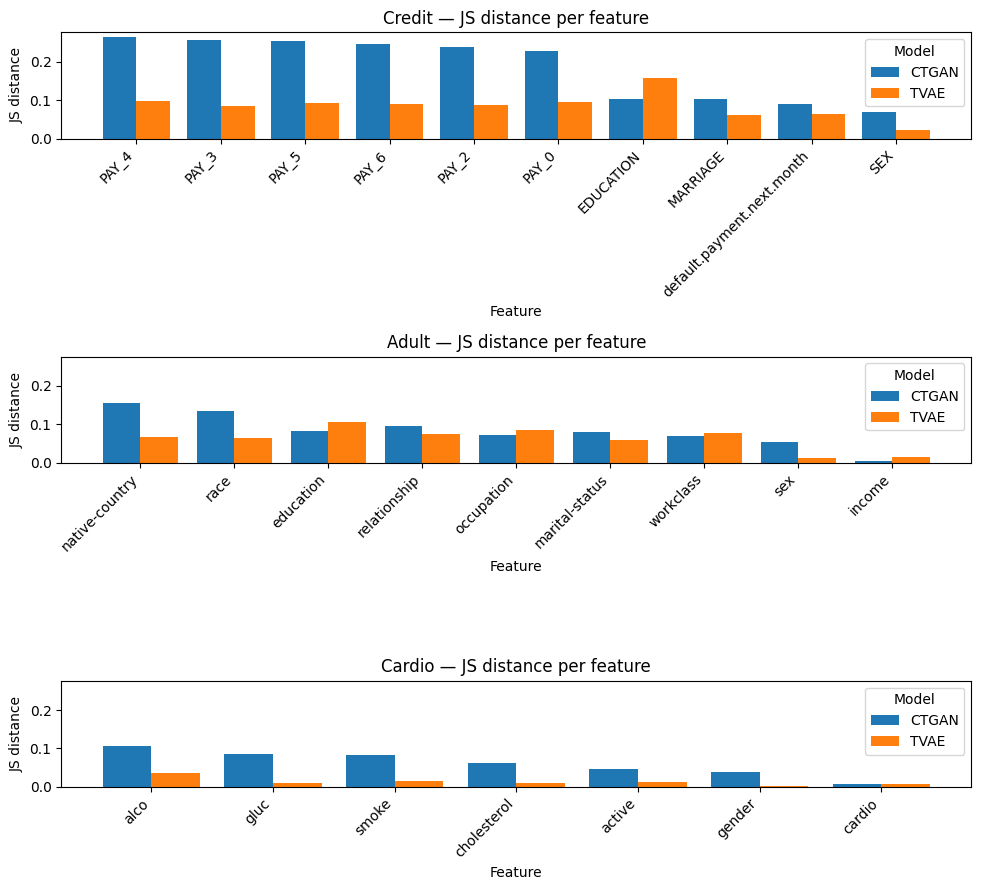

In [36]:
fig, axes = plot_per_feature_bar_multi(
    js,
    metric_name="JS distance",
    sort_features=True,
    datasets_order=["credit", "adult", "cardio"],
)
plt.show()


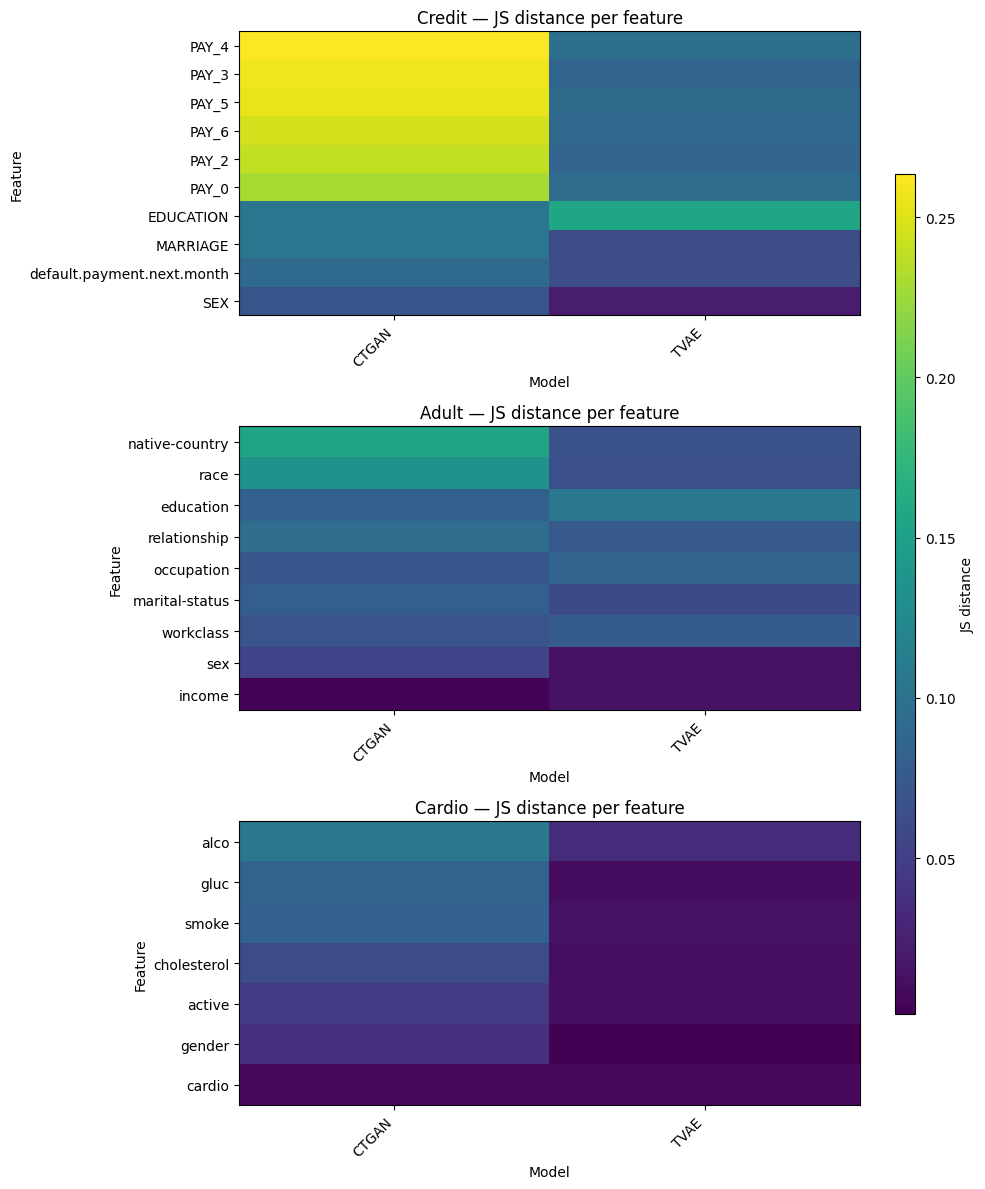

In [104]:

fig, axes = plot_per_feature_heatmap_multi(
    js,
    metric_name="JS distance",
    sort_features=True,
    # optional explicit ordering:
    datasets_order=["credit", "adult", "cardio"],
)
plt.show()


(<Figure size 400x400 with 2 Axes>,
 <Axes: title={'center': 'Credit (categorical) — JS divergence per feature'}, xlabel='Model', ylabel='Feature'>)

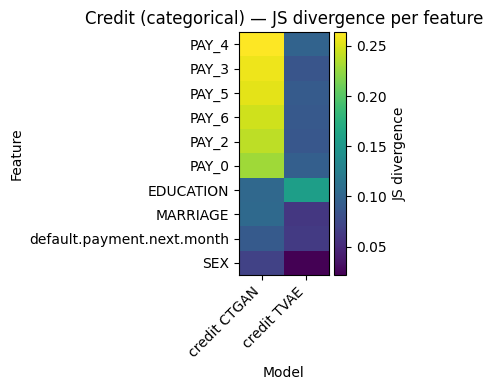

In [ ]:
plot_per_feature_heatmap(
    js_credit,
    metric_name="JS divergence",
    dataset_name="Credit (categorical)"
)


fig, axes = plot_per_feature_heatmap_multi(
    cohen,
    metric_name="JS distance",
    sort_features=True,
    # optional explicit ordering:
    datasets_order=["credit", "adult", "cardio"],
)
plt.show()

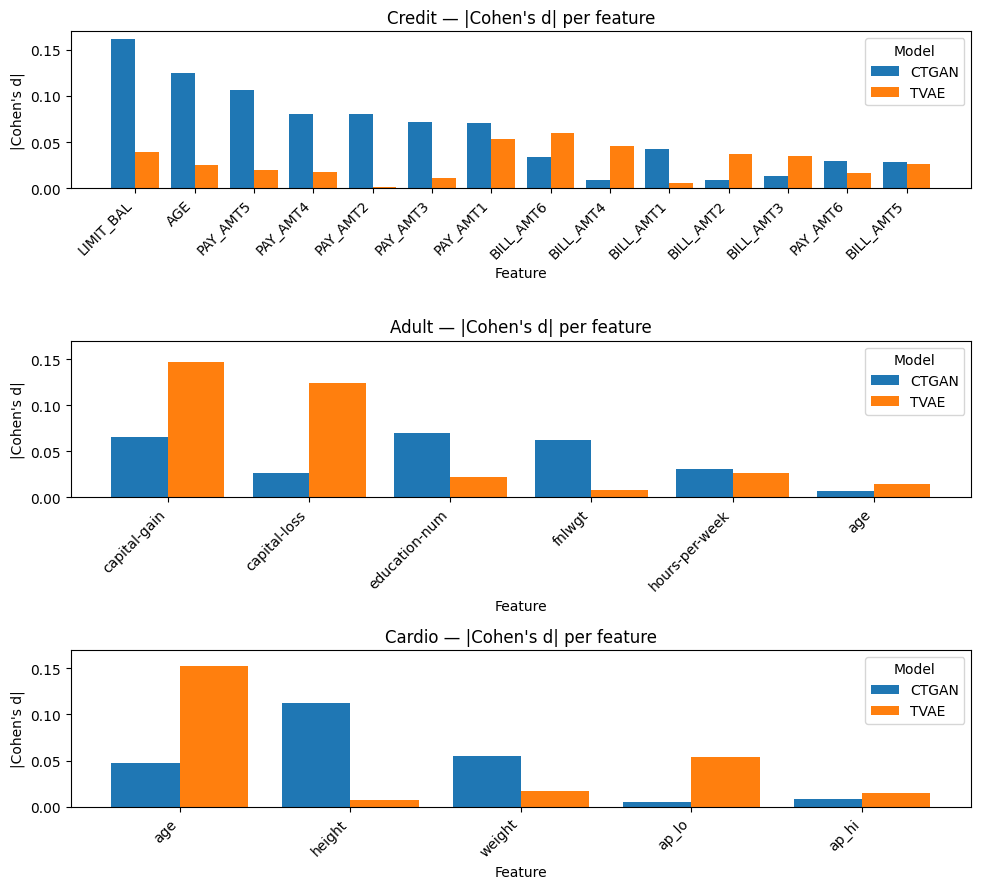

In [26]:
fig, axes = plot_per_feature_bar_multi(
    cohen,
    metric_name="|Cohen's d|",
    sort_features=True,
    datasets_order=["credit", "adult", "cardio"],
)
plt.show()


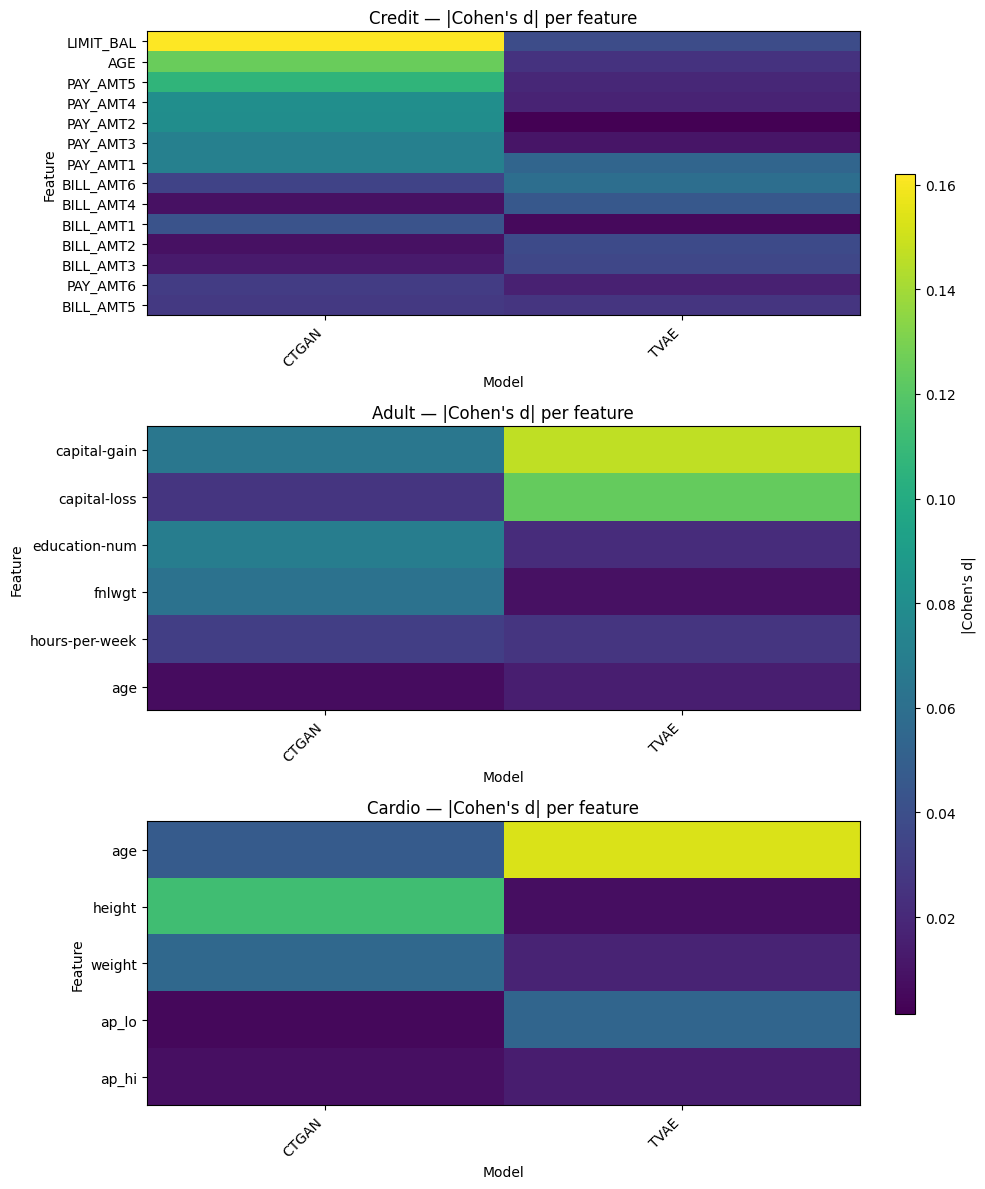

In [105]:
# plot_per_feature_heatmap(
#     cohen,
#     metric_name="|Cohen's d|",
#     dataset_name="Credit (numeric)"
# )

fig, axes = plot_per_feature_heatmap_multi(
    cohen,
    metric_name="|Cohen's d|",
    sort_features=True,
    # optional explicit ordering:
    datasets_order=["credit", "adult", "cardio"],
)
# plt.show()

In [55]:
corr_ratio = {}
pearson = {}
cramer = {}

for key, results in dict_results_credit.items() :
    corr_ratio[key] = results['resemblance_evaluation_results']['categorical_numerical_multivariate']
    pearson[key] = results['resemblance_evaluation_results']['numerical_multivariate']
    cramer[key] = results['resemblance_evaluation_results']['categorical_multivariate']


for key, results in dict_results_adult.items() :
    corr_ratio[key] = results['resemblance_evaluation_results']['categorical_numerical_multivariate']
    pearson[key] = results['resemblance_evaluation_results']['numerical_multivariate']
    cramer[key] = results['resemblance_evaluation_results']['categorical_multivariate']



for key, results in dict_results_cardio.items() :
    corr_ratio[key] = results['resemblance_evaluation_results']['categorical_numerical_multivariate']
    pearson[key] = results['resemblance_evaluation_results']['numerical_multivariate']
    cramer[key] = results['resemblance_evaluation_results']['categorical_multivariate']

In [56]:
summary_df = build_summary_df(
    corr_ratio,
    pearson,
    cramer
)
print(summary_df)

  dataset  model  diff_norm_corr_ratio  corr_ratio_spearman  \
0   adult  CTGAN                0.3561             0.910806   
1   adult   TVAE                0.4690             0.849133   
2  cardio  CTGAN                0.3699             0.834734   
3  cardio   TVAE                0.3473             0.728852   
4  credit  CTGAN                0.6158             0.936962   
5  credit   TVAE                0.7492             0.894260   

   pearson_norm_diff  pearson_spearman  diff_norm_cramer  cramer_spearman  
0             0.2148          0.810714            0.2967         0.913256  
1             0.2005          0.435714            0.4572         0.866152  
2             0.5061          0.418182            0.2621         0.810390  
3             0.2789          0.551515            0.2510         0.887013  
4             0.9750          0.793741            0.7986         0.940711  
5             0.8974          0.843319            1.0010         0.889196  


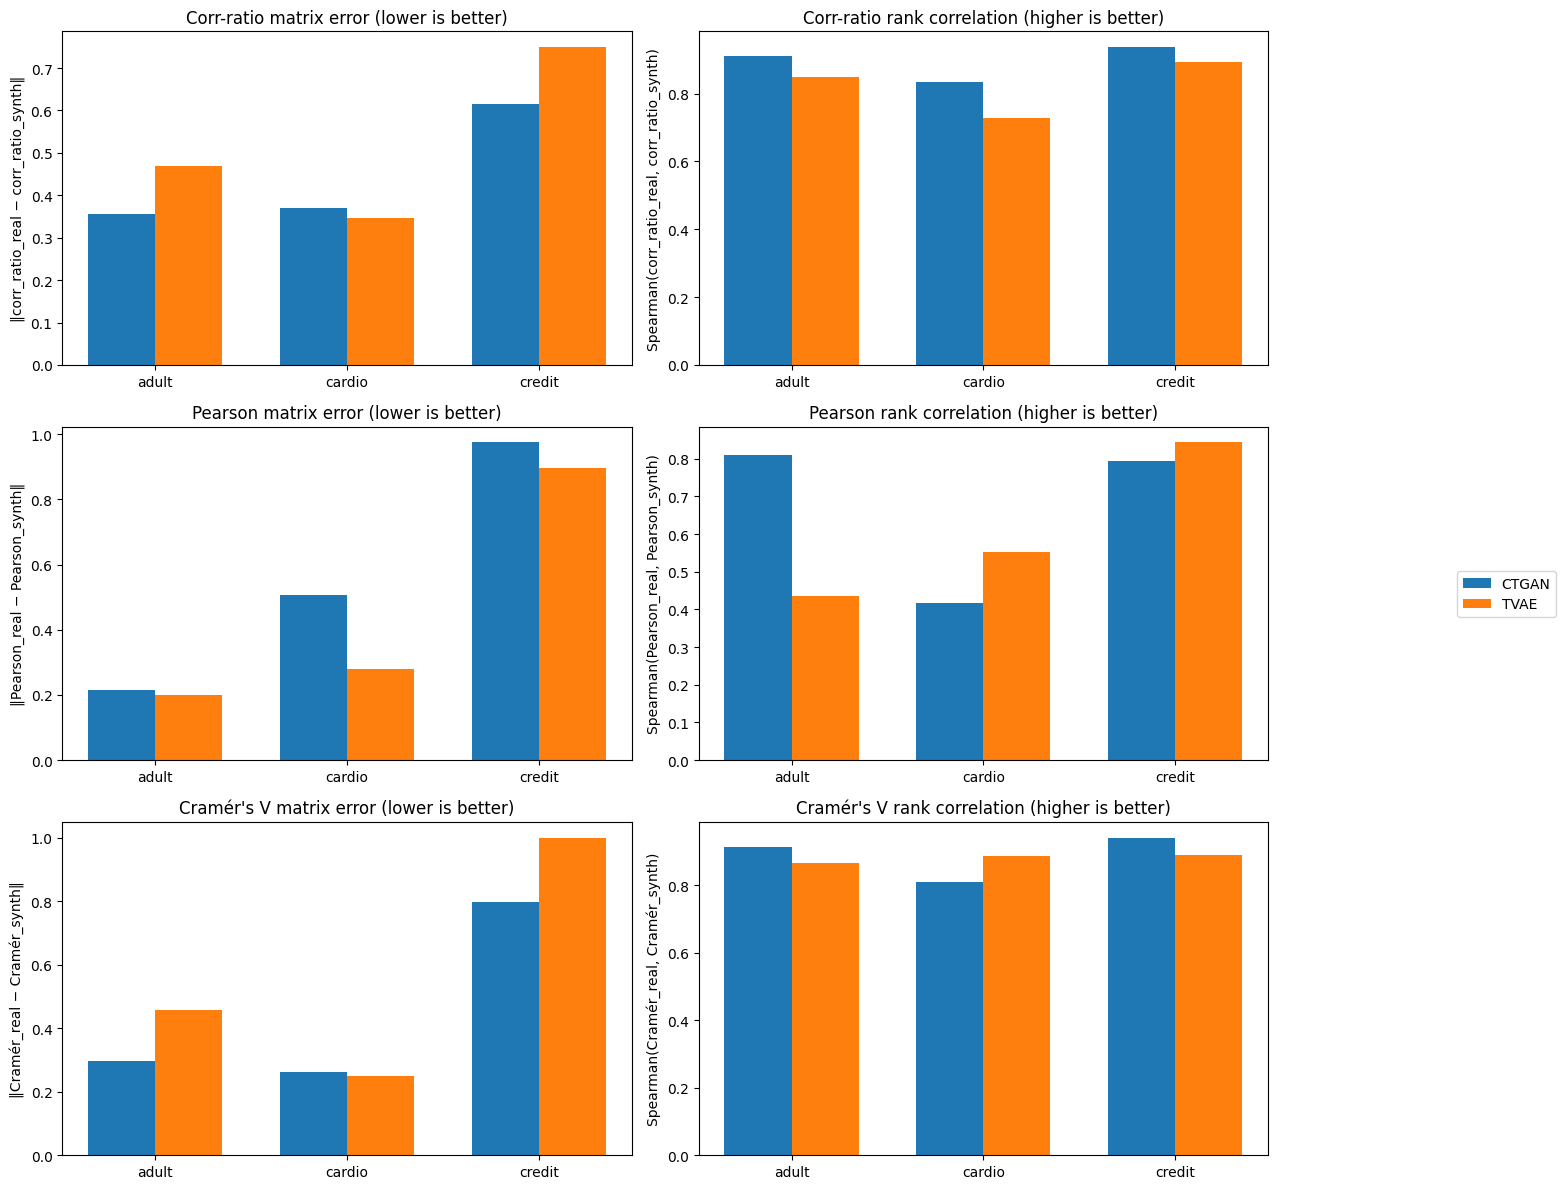

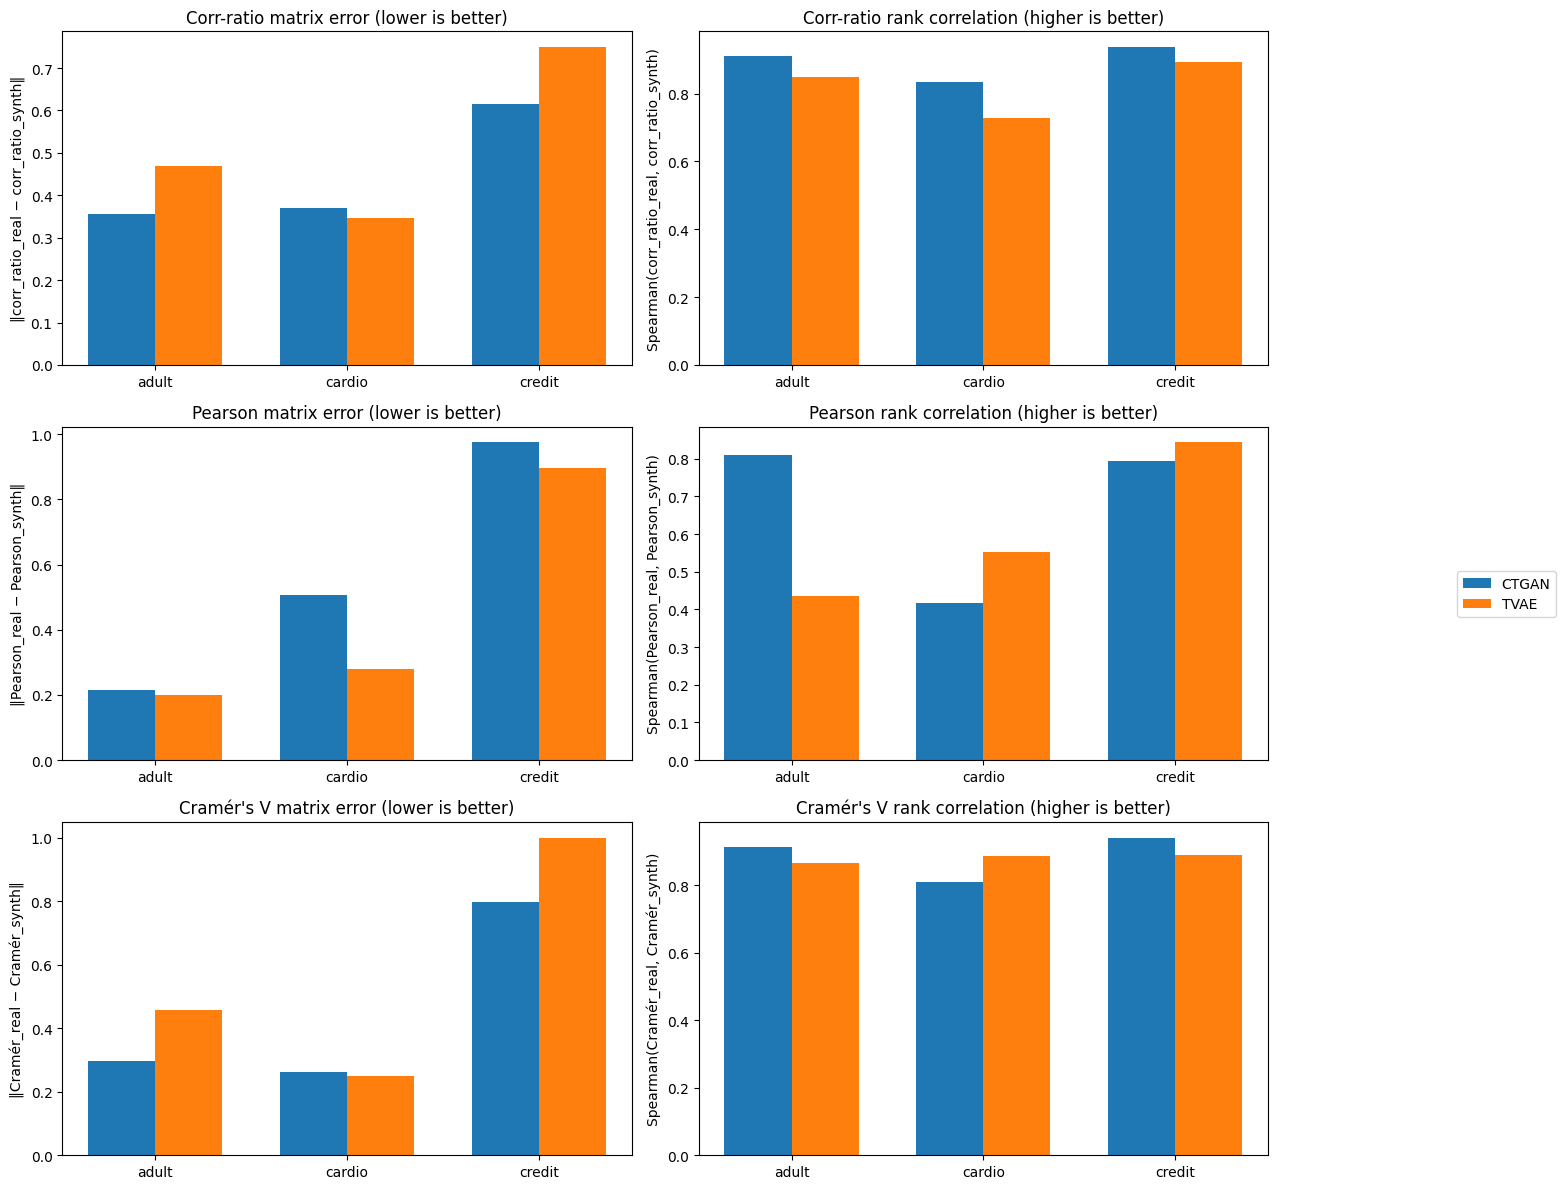

In [60]:
plot_matrix_errors_vs_rankcorr(summary_df)

In [46]:
tstr_trtr = {}
credit_ctgan_utility = load_all_results(f'{UTILITY_ONLY_DIR}/credit_ctgan_baseline').to_legacy_dict()
credit_tvae_utility = load_all_results(f'{UTILITY_ONLY_DIR}/credit_tvae_baseline').to_legacy_dict()
adult_ctgan_utility = load_all_results(f'{UTILITY_ONLY_DIR}/adult_ctgan_baseline').to_legacy_dict()
adult_tvae_utility = load_all_results(f'{UTILITY_ONLY_DIR}/adult_tvae_baseline').to_legacy_dict()
cardio_ctgan_utility = load_all_results(f'{UTILITY_ONLY_DIR}/cardio_ctgan_baseline').to_legacy_dict()
cardio_tvae_utility = load_all_results(f'{UTILITY_ONLY_DIR}/cardio_tvae_baseline').to_legacy_dict()

tstr_trtr['credit_ctgan_trtr'] = credit_ctgan_utility['utility_evaluation_results']['train_real_test_real_results']
tstr_trtr['credit_ctgan_tstr'] = credit_ctgan_utility['utility_evaluation_results']['train_synthetic_test_real_results']

tstr_trtr['credit_tvae_trtr'] = credit_tvae_utility['utility_evaluation_results']['train_real_test_real_results']
tstr_trtr['credit_tvae_tstr'] = credit_tvae_utility['utility_evaluation_results']['train_synthetic_test_real_results']

tstr_trtr['adult_ctgan_trtr'] = adult_ctgan_utility['utility_evaluation_results']['train_real_test_real_results']
tstr_trtr['adult_ctgan_tstr'] = adult_ctgan_utility['utility_evaluation_results']['train_synthetic_test_real_results']

tstr_trtr['adult_tvae_trtr'] = adult_tvae_utility['utility_evaluation_results']['train_real_test_real_results']
tstr_trtr['adult_tvae_tstr'] = adult_tvae_utility['utility_evaluation_results']['train_synthetic_test_real_results']

tstr_trtr['cardio_ctgan_trtr'] = cardio_ctgan_utility['utility_evaluation_results']['train_real_test_real_results']
tstr_trtr['cardio_ctgan_tstr'] = cardio_ctgan_utility['utility_evaluation_results']['train_synthetic_test_real_results']

tstr_trtr['cardio_tvae_trtr'] = cardio_tvae_utility['utility_evaluation_results']['train_real_test_real_results']
tstr_trtr['cardio_tvae_tstr'] = cardio_tvae_utility['utility_evaluation_results']['train_synthetic_test_real_results']

In [18]:
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/adult_ctgan_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    tstr_trtr['adult_ctgan_trtr'] = pickle.load(file)

tstr_trtr['adult_ctgan_trtr']

(               accuracy  precision_avg  recall_avg    f1_avg  \
 CART           0.812112       0.598696    0.620645  0.609473   
 KNN            0.823905       0.644951    0.566303  0.603074   
 LDA            0.843007       0.708333    0.570203  0.631806   
 LR             0.805847       0.559062    0.842954  0.672265   
 NB             0.541736       0.333579    0.942018  0.492691   
 Random Forest  0.851360       0.722396    0.602184  0.656835   
 SVM            0.786500       0.530111    0.846854  0.652052   
 XGBoost        0.874271       0.778053    0.654446  0.710917   
 
                balanced_accuracy  precision_weighted  recall_weighted  \
 CART                    0.745988            0.814560         0.812112   
 KNN                     0.734941            0.817401         0.823905   
 LDA                     0.748793            0.835347         0.843007   
 LR                      0.818662            0.851828         0.805847   
 NB                      0.679975          

In [41]:
tstr_trtr = {}

with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/credit_ctgan_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    tstr_trtr['credit_ctgan_trtr'] = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/credit_ctgan_eps_none_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    tstr_trtr['credit_ctgan_tstr'] = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/credit_tvae_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    tstr_trtr['credit_tvae_trtr'] = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/credit_tvae_eps_none_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    tstr_trtr['credit_tvae_tstr'] = pickle.load(file)


with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/adult_ctgan_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    tstr_trtr['adult_ctgan_trtr'] = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/adult_ctgan_eps_none_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    tstr_trtr['adult_ctgan_tstr'] = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/adult_tvae_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    tstr_trtr['adult_tvae_trtr'] = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/adult_tvae_eps_none_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    tstr_trtr['adult_tvae_tstr'] = pickle.load(file)


with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/cardio_ctgan_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    tstr_trtr['cardio_ctgan_trtr'] = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/cardio_ctgan_eps_none_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    tstr_trtr['cardio_ctgan_tstr'] = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/cardio_tvae_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    tstr_trtr['cardio_tvae_trtr'] = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/cardio_tvae_eps_none_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    tstr_trtr['cardio_tvae_tstr'] = pickle.load(file)

In [47]:
tstr_trtr

{'credit_ctgan_trtr':                accuracy_mean  accuracy_std  precision_avg_mean  \
 CART                0.721167  2.618312e-03            0.375323   
 KNN                 0.807500  1.110223e-16            0.601282   
 LDA                 0.819000  0.000000e+00            0.648755   
 NB                  0.805833  1.110223e-16            0.637546   
 LR                  0.773667  1.110223e-16            0.485641   
 Random Forest       0.816567  9.780934e-04            0.654455   
 SVM                 0.774000  0.000000e+00            0.486435   
 XGBoost             0.822000  1.178511e-03            0.668003   
 
                precision_avg_std  recall_avg_mean  recall_avg_std  \
 CART                4.577676e-03         0.412567    4.087962e-03   
 KNN                 1.110223e-16         0.357197    5.551115e-17   
 LDA                 1.110223e-16         0.376999    5.551115e-17   
 NB                  0.000000e+00         0.261234    0.000000e+00   
 LR                  0.0

In [48]:
 # Replace this with your actual dict name
utility_results = tstr_trtr

In [49]:
utility_results

{'credit_ctgan_trtr':                accuracy_mean  accuracy_std  precision_avg_mean  \
 CART                0.721167  2.618312e-03            0.375323   
 KNN                 0.807500  1.110223e-16            0.601282   
 LDA                 0.819000  0.000000e+00            0.648755   
 NB                  0.805833  1.110223e-16            0.637546   
 LR                  0.773667  1.110223e-16            0.485641   
 Random Forest       0.816567  9.780934e-04            0.654455   
 SVM                 0.774000  0.000000e+00            0.486435   
 XGBoost             0.822000  1.178511e-03            0.668003   
 
                precision_avg_std  recall_avg_mean  recall_avg_std  \
 CART                4.577676e-03         0.412567    4.087962e-03   
 KNN                 1.110223e-16         0.357197    5.551115e-17   
 LDA                 1.110223e-16         0.376999    5.551115e-17   
 NB                  0.000000e+00         0.261234    0.000000e+00   
 LR                  0.0

In [44]:

utility_long = build_utility_long(utility_results)

In [51]:
utility_long_meanstd = build_utility_long_meanstd(utility_results)

In [56]:
print(utility_long_meanstd)

     dataset  model regime classifier             metric      mean       std
0     credit  CTGAN   trtr       CART           accuracy  0.721167  0.002618
1     credit  CTGAN   trtr       CART      precision_avg  0.375323  0.004578
2     credit  CTGAN   trtr       CART         recall_avg  0.412567  0.004088
3     credit  CTGAN   trtr       CART             f1_avg  0.393055  0.003901
4     credit  CTGAN   trtr       CART  balanced_accuracy  0.610092  0.002666
...      ...    ...    ...        ...                ...       ...       ...
1531  cardio   TVAE   tstr    XGBoost            roc_auc  0.774715  0.000360
1532  cardio   TVAE   tstr    XGBoost      avg_precision  0.758038  0.000634
1533  cardio   TVAE   tstr    XGBoost                mcc  0.432555  0.001140
1534  cardio   TVAE   tstr    XGBoost        cohen_kappa  0.426750  0.001263
1535  cardio   TVAE   tstr    XGBoost           log_loss  0.576401  0.000254

[1536 rows x 7 columns]


In [55]:
print(utility_long)

     dataset  model regime classifier             metric     value
0     credit  CTGAN   trtr       CART           accuracy  0.720500
1     credit  CTGAN   trtr       CART      precision_avg  0.374309
2     credit  CTGAN   trtr       CART         recall_avg  0.412795
3     credit  CTGAN   trtr       CART             f1_avg  0.392611
4     credit  CTGAN   trtr       CART  balanced_accuracy  0.609747
...      ...    ...    ...        ...                ...       ...
1531  cardio   TVAE   tstr    XGBoost            roc_auc  0.775240
1532  cardio   TVAE   tstr    XGBoost      avg_precision  0.757858
1533  cardio   TVAE   tstr    XGBoost                mcc  0.433326
1534  cardio   TVAE   tstr    XGBoost        cohen_kappa  0.427887
1535  cardio   TVAE   tstr    XGBoost           log_loss  0.575860

[1536 rows x 6 columns]


In [59]:
utility_long = utility_long_meanstd.rename(columns={"mean": "value"})

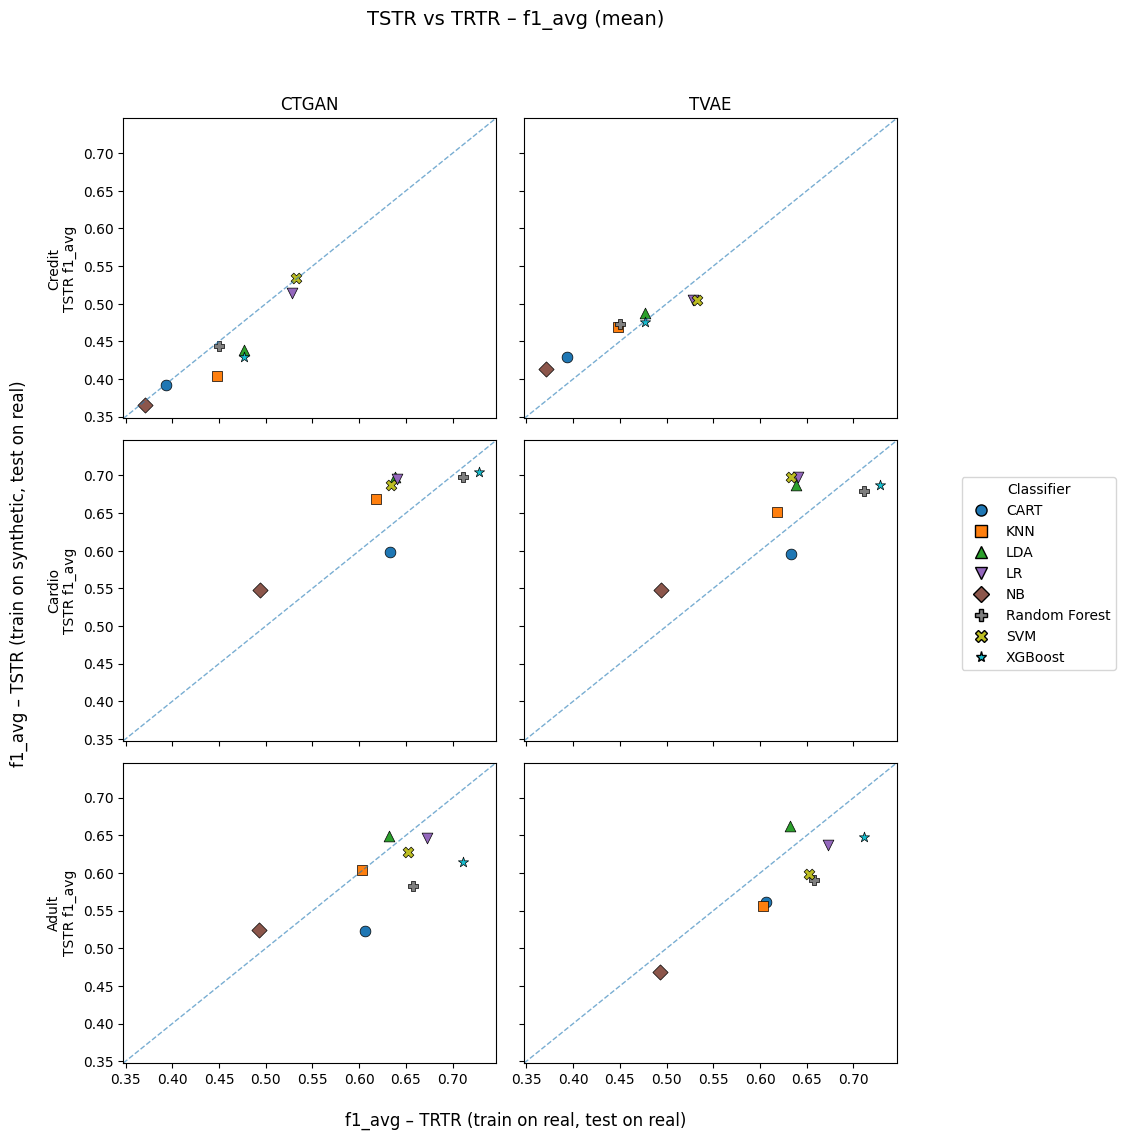

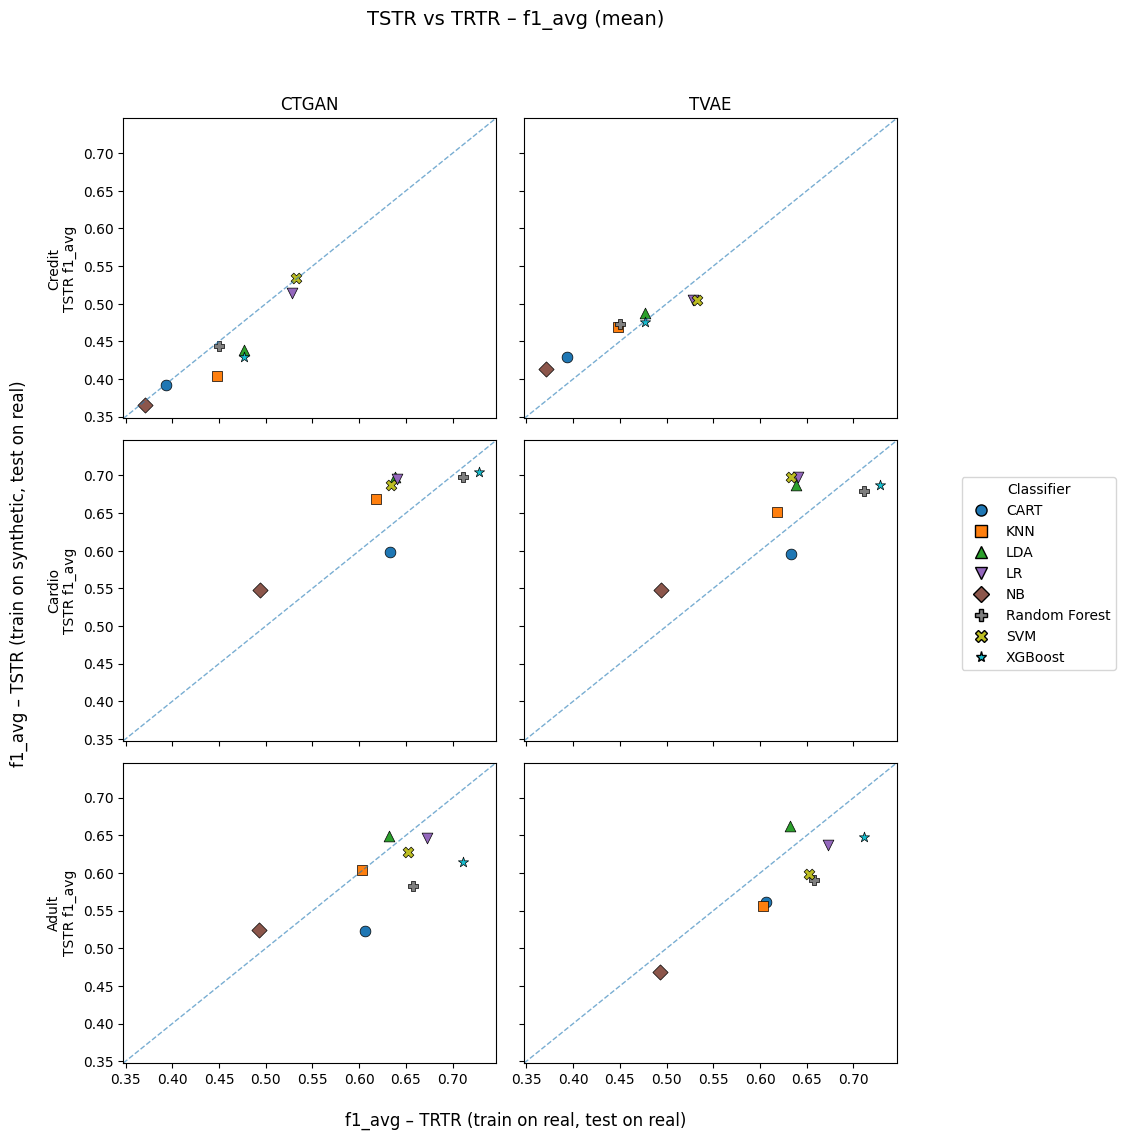

In [58]:
multi_scatter_trtr_vs_tstr_meanstd(utility_long_meanstd, "f1_avg")

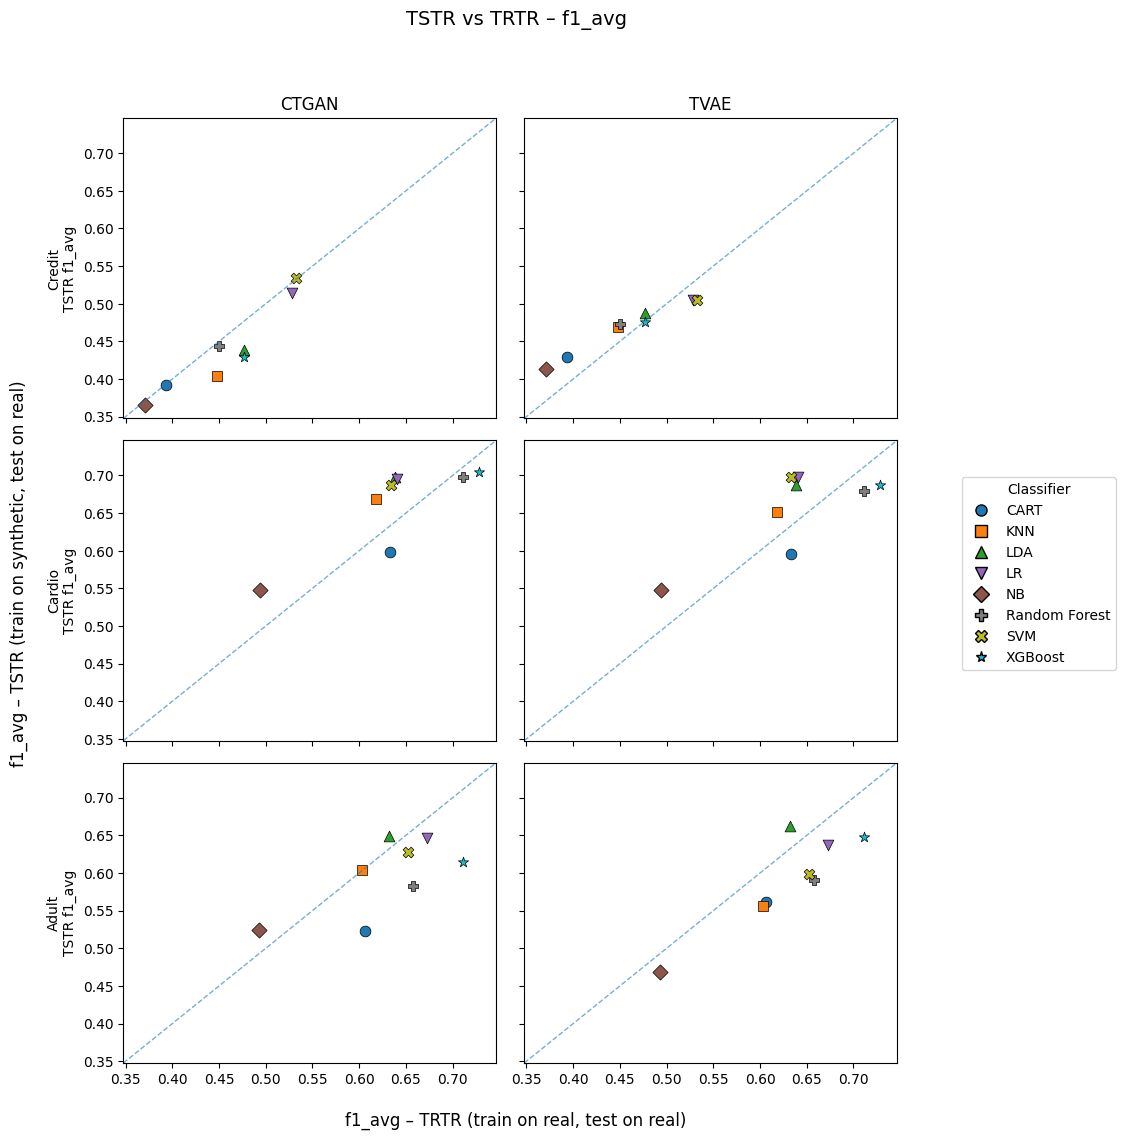

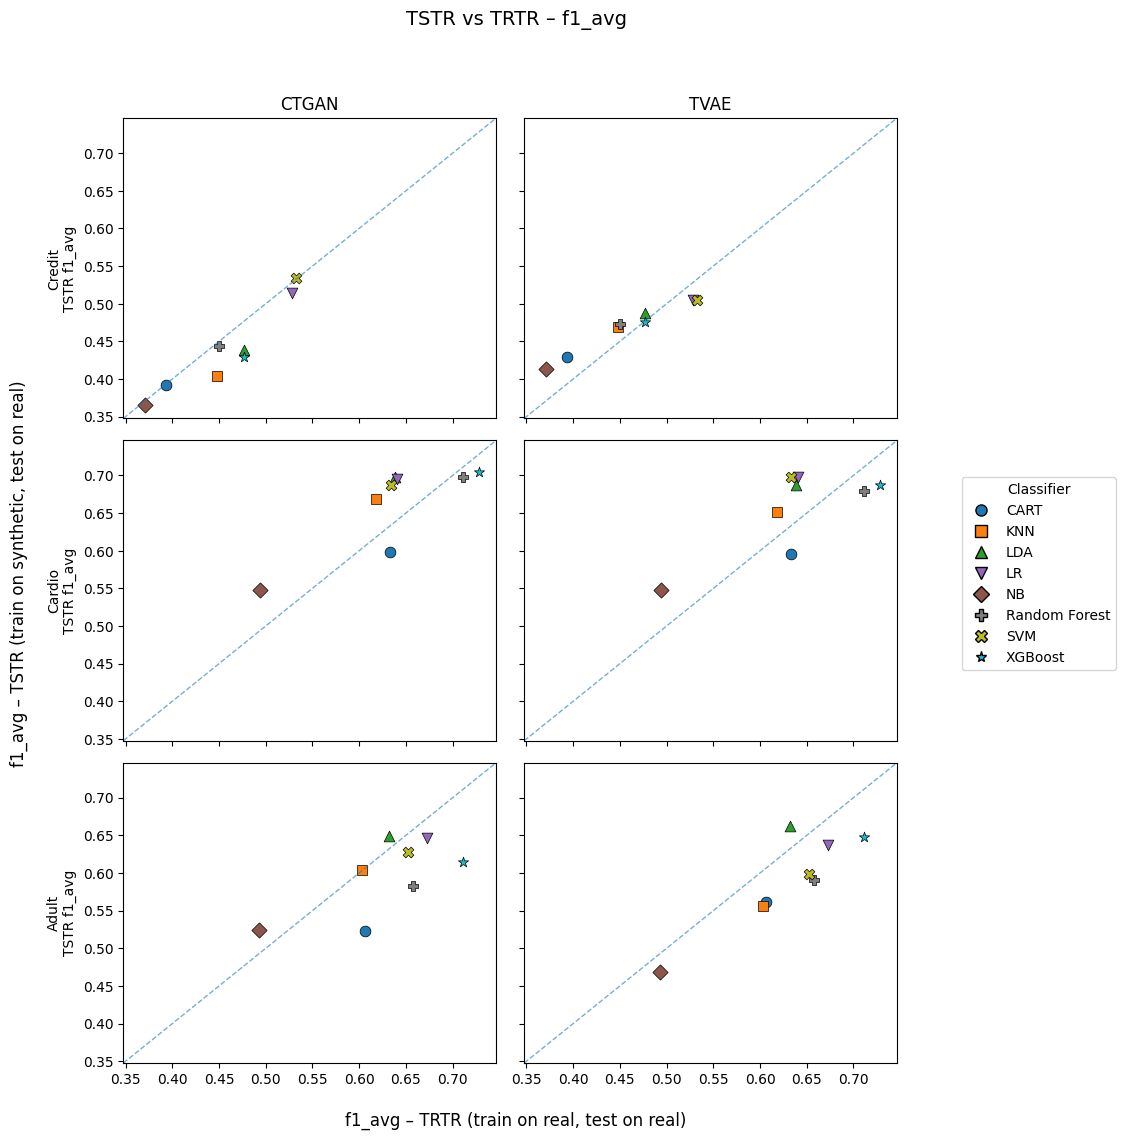

In [60]:
multi_scatter_trtr_vs_tstr(utility_long, "f1_avg")

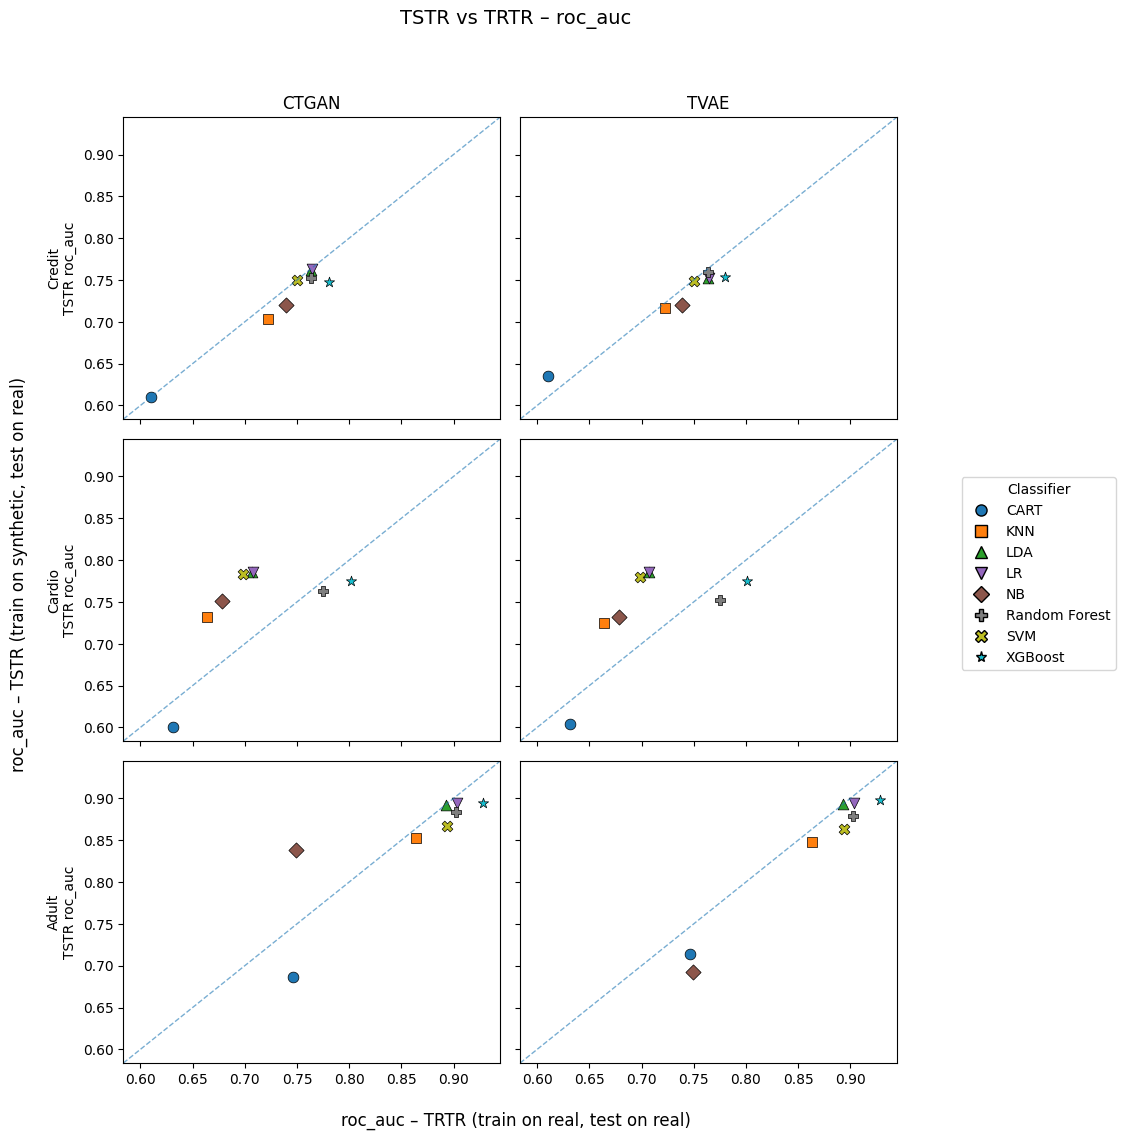

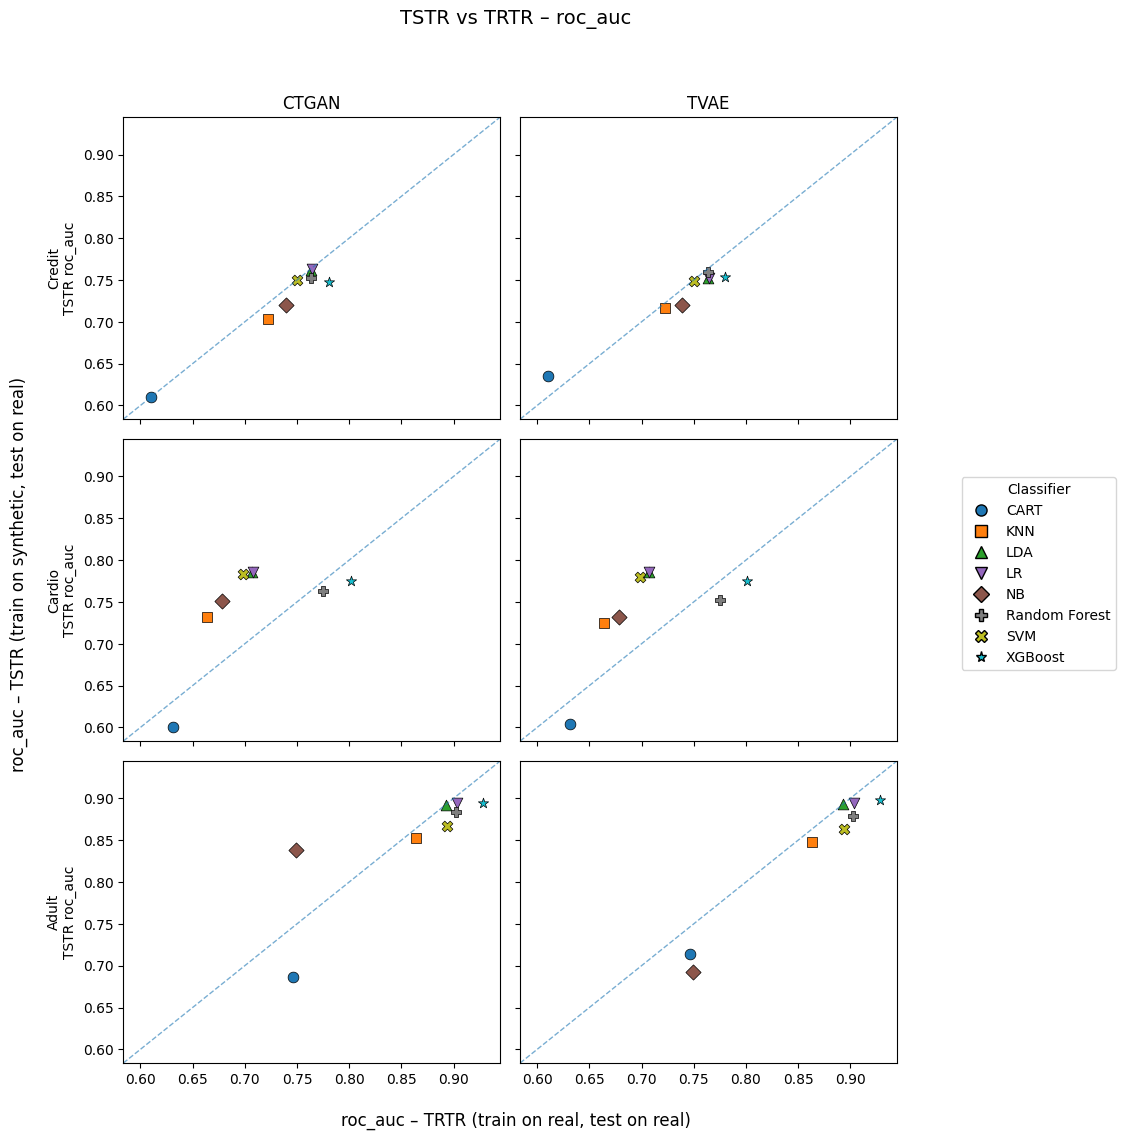

In [49]:
multi_scatter_trtr_vs_tstr(utility_long, "roc_auc")

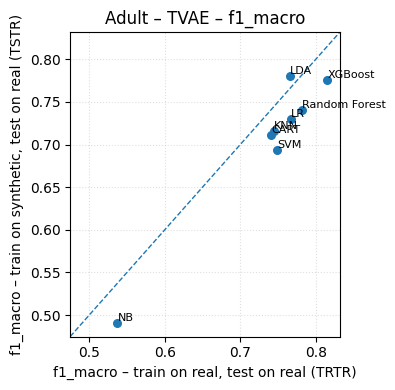

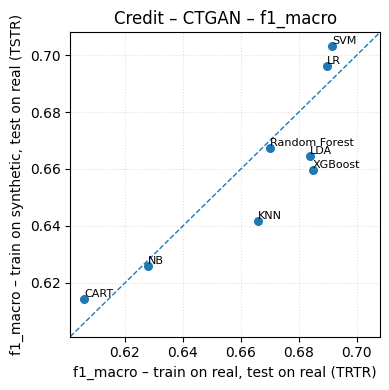

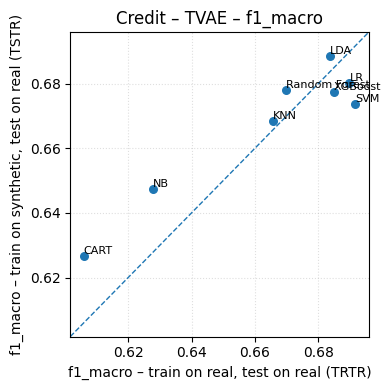

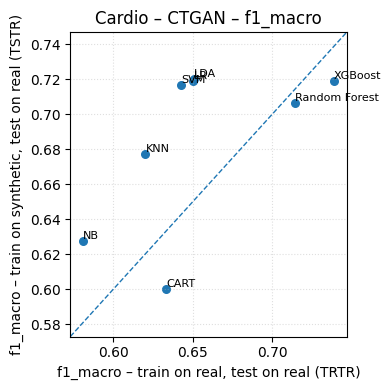

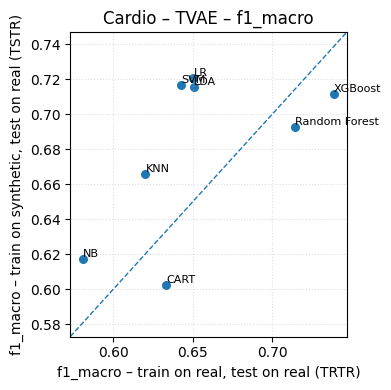

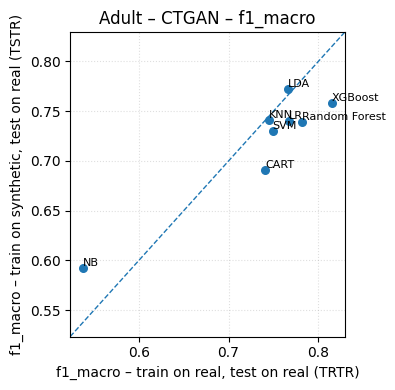

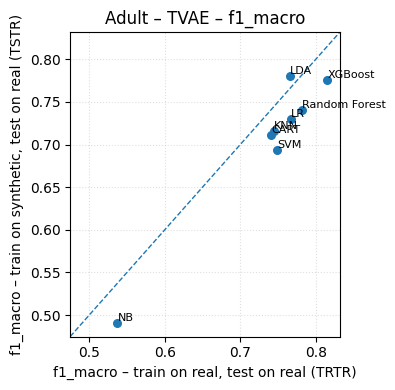

In [61]:
# CREDIT
scatter_trtr_vs_tstr(utility_long, "credit", "CTGAN", metric="f1_macro")
scatter_trtr_vs_tstr(utility_long, "credit", "TVAE",  metric="f1_macro")

# CARDIO
scatter_trtr_vs_tstr(utility_long, "cardio", "CTGAN", metric="f1_macro")
scatter_trtr_vs_tstr(utility_long, "cardio", "TVAE",  metric="f1_macro")

# ADULT
scatter_trtr_vs_tstr(utility_long, "adult", "CTGAN", metric="f1_macro")
scatter_trtr_vs_tstr(utility_long, "adult", "TVAE",  metric="f1_macro")


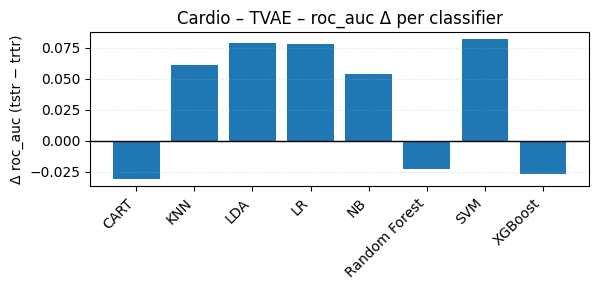

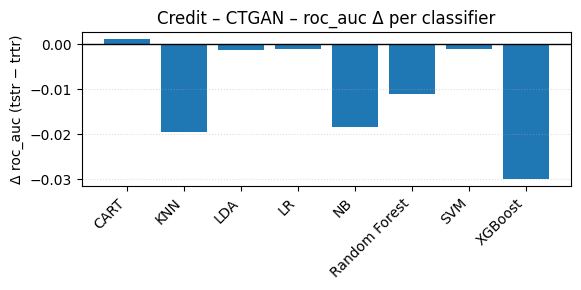

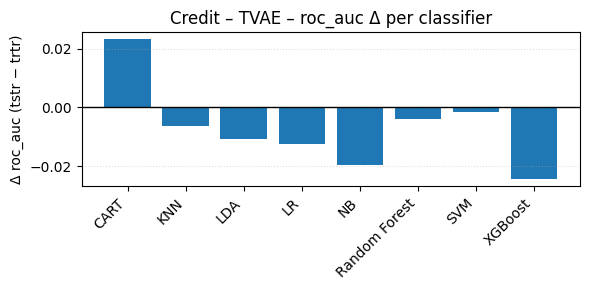

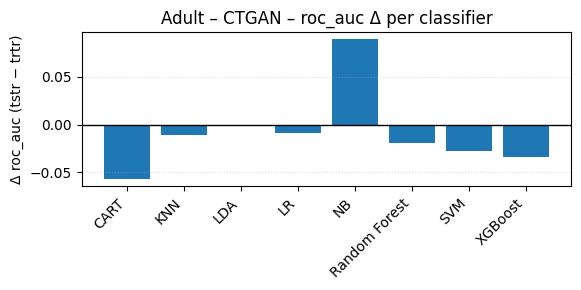

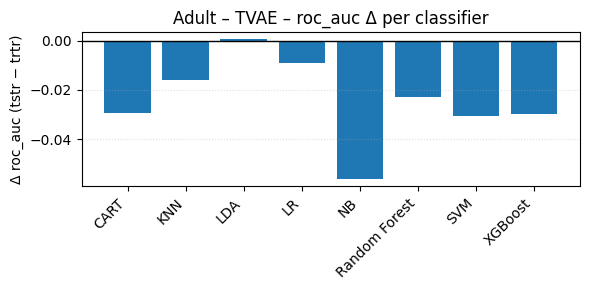

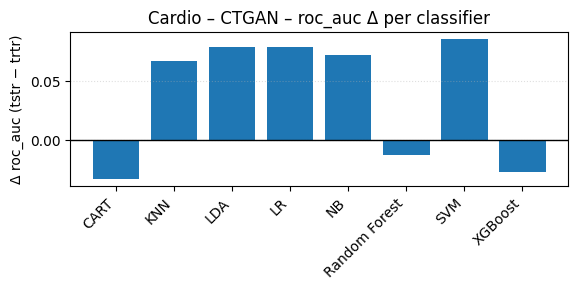

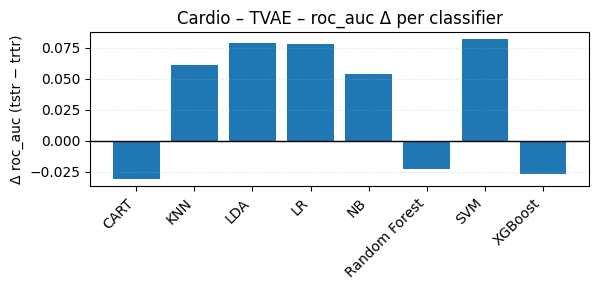

In [62]:
bar_delta_tstr_trtr(utility_long, "credit", "CTGAN", metric="roc_auc")
bar_delta_tstr_trtr(utility_long, "credit", "TVAE",  metric="roc_auc")
bar_delta_tstr_trtr(utility_long, "adult", "CTGAN", metric="roc_auc")
bar_delta_tstr_trtr(utility_long, "adult", "TVAE",  metric="roc_auc")
bar_delta_tstr_trtr(utility_long, "cardio", "CTGAN", metric="roc_auc")
bar_delta_tstr_trtr(utility_long, "cardio", "TVAE",  metric="roc_auc")


In [8]:
predictions_credit = {}
predictions_adult = {}
predictions_cardio = {}

with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_real_credit_ctgan_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    predictions_credit['credit_real_ctgan'] = pickle.load(file)

with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_synth_credit_ctgan_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    predictions_credit['credit_synth_ctgan'] = pickle.load(file)

with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_real_credit_tvae_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    predictions_credit['credit_real_tvae'] = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_synth_credit_tvae_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    predictions_credit['credit_synth_tvae'] = pickle.load(file)


with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_real_adult_ctgan_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    predictions_adult['adult_real_ctgan'] = pickle.load(file)

with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_synth_adult_ctgan_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    predictions_adult['adult_synth_ctgan'] = pickle.load(file)


with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_real_adult_tvae_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    predictions_adult['adult_real_tvae'] = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_synth_adult_tvae_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    predictions_adult['adult_synth_tvae'] = pickle.load(file)

with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_real_cardio_ctgan_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    predictions_cardio['cardio_real_ctgan'] = pickle.load(file)

with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_synth_cardio_ctgan_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    predictions_cardio['cardio_synth_ctgan'] = pickle.load(file)

with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_real_cardio_tvae_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    predictions_cardio['cardio_real_tvae'] = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_synth_cardio_tvae_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    predictions_cardio['cardio_synth_tvae'] = pickle.load(file)

    

In [11]:
result_classification_credit = result_classification(predictions_credit, df_real_credit_card_test,['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6'])
result_regression_credit= result_regression(predictions_credit, df_real_credit_card_test, ['BILL_AMT1','BILL_AMT2','PAY_AMT1','PAY_AMT2'])

cat_risk = [column for column in cardio_risk_column if column in cat_list_cardio]
result_classification_cardio= result_classification(predictions_cardio, df_real_cardio_test,cat_risk)
num_risk = [column for column in cardio_risk_column if column in num_list_cardio]
result_regression_cardio= result_regression(predictions_cardio, df_real_cardio_test,num_risk)

cat_risk = [column for column in adult_risk_column if column in cat_list_adult]
result_classification_adult= result_classification(predictions_adult, df_real_adult_test,cat_risk)
num_risk = [column for column in adult_risk_column if column in num_list_adult]
result_regression_adult= result_regression(predictions_adult, df_real_adult_test,num_risk)

In [12]:
result_regression = result_regression_credit |result_regression_adult | result_regression_cardio

In [13]:
result_classification = result_classification_credit |result_classification_adult | result_classification_cardio

In [ ]:
result_regression

In [34]:

attr_clf_long = build_attr_clf_long(result_classification)

In [35]:
attr_clf_long

,dataset,model,data_type,attribute,balanced_accuracy,macro_f1,accuracy
0,credit,CTGAN,real,PAY_0,0.108263,0.085963,0.491833
1,credit,CTGAN,real,PAY_2,0.120395,0.100586,0.524333
2,credit,CTGAN,real,PAY_3,0.097996,0.081612,0.519500
3,credit,CTGAN,real,PAY_4,0.104529,0.085491,0.535833
4,credit,CTGAN,real,PAY_5,0.113979,0.090138,0.553000
5,credit,CTGAN,real,PAY_6,0.113477,0.087214,0.542833
6,credit,CTGAN,synth,PAY_0,0.110735,0.092236,0.443167
7,credit,CTGAN,synth,PAY_2,0.122487,0.118631,0.451833
8,credit,CTGAN,synth,PAY_3,0.099126,0.093816,0.470667
9,credit,CTGAN,synth,PAY_4,0.104490,0.080071,0.525333


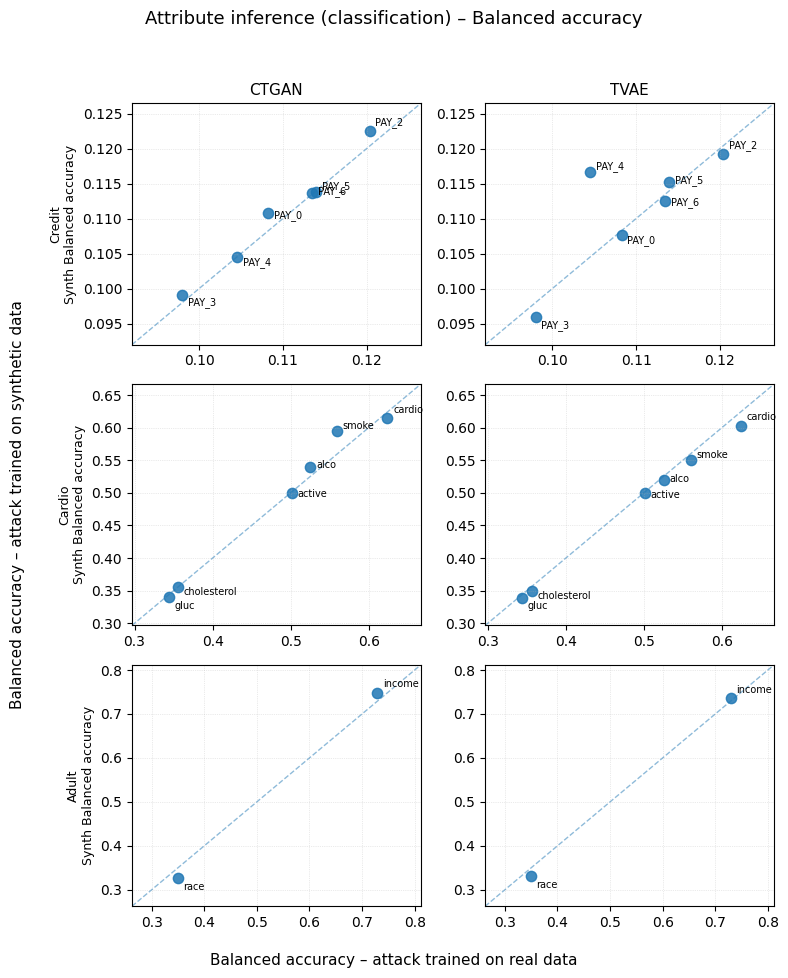

In [40]:
fig_ba = make_attr_clf_grid(attr_clf_long, metric="balanced_accuracy")

In [74]:

attr_reg_long = build_attr_reg_long(result_regression)

In [62]:
attr_reg_long

,dataset,model,data_type,attribute,mse,rmse,r2
0,credit,CTGAN,real,BILL_AMT1,5.468560e+09,73949.715757,0.016218
1,credit,CTGAN,real,BILL_AMT2,5.132743e+09,71643.165319,0.014177
2,credit,CTGAN,real,BILL_AMT3,4.788067e+09,69195.857598,0.013742
3,credit,CTGAN,real,BILL_AMT4,4.218446e+09,64949.562203,0.012705
4,credit,CTGAN,real,BILL_AMT5,3.731757e+09,61088.108722,0.011221
...,...,...,...,...,...,...,...
63,cardio,CTGAN,synth,ap_hi,2.060342e+04,143.538907,0.001089
64,cardio,TVAE,real,ap_lo,2.926750e+04,171.077466,0.001452
65,cardio,TVAE,real,ap_hi,2.060347e+04,143.539073,0.001086
66,cardio,TVAE,synth,ap_lo,2.930814e+04,171.196189,0.000066


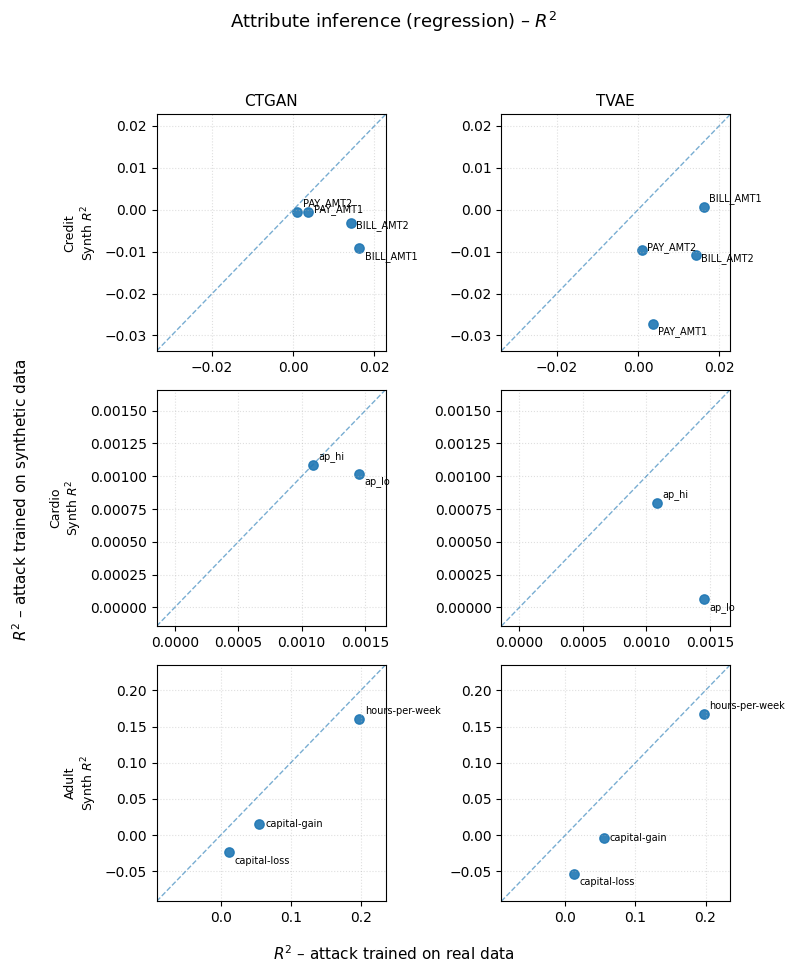

In [75]:
# Regression-risk figure:
fig_r2 = make_attr_reg_grid(attr_reg_long, metric="r2")

In [27]:
result_anonym_credit = get_anonymeter_result(dict_results_credit)
result_anonym_adult = get_anonymeter_result(dict_results_adult)
result_anonym_cardio = get_anonymeter_result(dict_results_cardio)

In [28]:
result_anonym = result_anonym_credit | result_anonym_adult | result_anonym_cardio

In [29]:
result_anonym

{'credit CTGAN': {'run_0': {'singling_univariate': AnonymeterResults(attacks_numbers=2000, attacks_succeeded=245, privacy_risk_original=0.12322368534867299, privacy_risk_control=0.09666487632783903, privacy_risk_naive=0.02391443155315765, specific_privacy=0.029400837324767528, specific_privacy_ci=0),
   'singling_multivariate': AnonymeterResults(attacks_numbers=2000, attacks_succeeded=263, privacy_risk_original=0.13220643192314172, privacy_risk_control=0.02618954948838195, privacy_risk_naive=0.03389526108034512, specific_privacy=0.10886808862963103, specific_privacy_ci=0),
   'linkability_attacks': AnonymeterResults(attacks_numbers=2000, attacks_succeeded=2000, privacy_risk_original=0.010440311691454566, privacy_risk_control=0.00694702135693895, privacy_risk_naive=0.004950855451501456, specific_privacy=0.0035177280665216453, specific_privacy_ci=0)},
  'run_1': {'singling_univariate': AnonymeterResults(attacks_numbers=2000, attacks_succeeded=254, privacy_risk_original=0.1277150586359073

In [30]:
import pandas as pd

def build_anonymeter_df(results):
    rows = []
    for key, runs in results.items():
        # key like 'credit CTGAN'
        dataset, generator = key.split()
        generator = generator.upper()  # CTGAN / TVAE

        for run_name, attacks in runs.items():
            run_id = int(run_name.split("_")[-1])  # e.g. run_0 -> 0

            for attack_type, res in attacks.items():
                # res is AnonymeterResults(...)
                rows.append({
                    "dataset": dataset,                     # credit / adult / cardio
                    "generator": generator,                 # CTGAN / TVAE
                    "run": run_id,
                    "attack": attack_type,                  # singling_univariate, ...
                    "attacks_numbers": res.attacks_numbers,
                    "attacks_succeeded": res.attacks_succeeded,
                    "privacy_risk_original": res.privacy_risk_original,
                    "privacy_risk_control": res.privacy_risk_control,
                    "privacy_risk_naive": res.privacy_risk_naive,
                    "specific_privacy": res.specific_privacy,
                    "specific_privacy_ci": res.specific_privacy_ci,
                })
    df = pd.DataFrame(rows)
    df["excess_risk"] = df["privacy_risk_original"] - df["privacy_risk_control"]
    return df

df_anon = build_anonymeter_df(result_anonym)


In [31]:
summary = (
    df_anon
    .groupby(["dataset", "generator", "attack"])
    .agg(
        mean_risk=("privacy_risk_original", "mean"),
        std_risk=("privacy_risk_original", "std"),
        mean_control=("privacy_risk_control", "mean"),
        mean_excess=("excess_risk", "mean"),
        mean_specific=("specific_privacy", "mean"),
    )
    .reset_index()
)

print(summary)


   dataset generator                 attack  mean_risk  std_risk  \
0    adult     CTGAN    linkability_attacks   0.018874  0.003571   
1    adult     CTGAN  singling_multivariate   0.179416  0.008061   
2    adult     CTGAN    singling_univariate   0.042329  0.004442   
3    adult      TVAE    linkability_attacks   0.020770  0.004000   
4    adult      TVAE  singling_multivariate   0.205266  0.005989   
5    adult      TVAE    singling_univariate   0.046421  0.005539   
6   cardio     CTGAN    linkability_attacks   0.003354  0.000905   
7   cardio     CTGAN  singling_multivariate   0.158157  0.006773   
8   cardio     CTGAN    singling_univariate   0.053108  0.002402   
9   cardio      TVAE    linkability_attacks   0.004003  0.001163   
10  cardio      TVAE  singling_multivariate   0.192141  0.005860   
11  cardio      TVAE    singling_univariate   0.061043  0.002959   
12  credit     CTGAN    linkability_attacks   0.008644  0.001928   
13  credit     CTGAN  singling_multivariate   0.

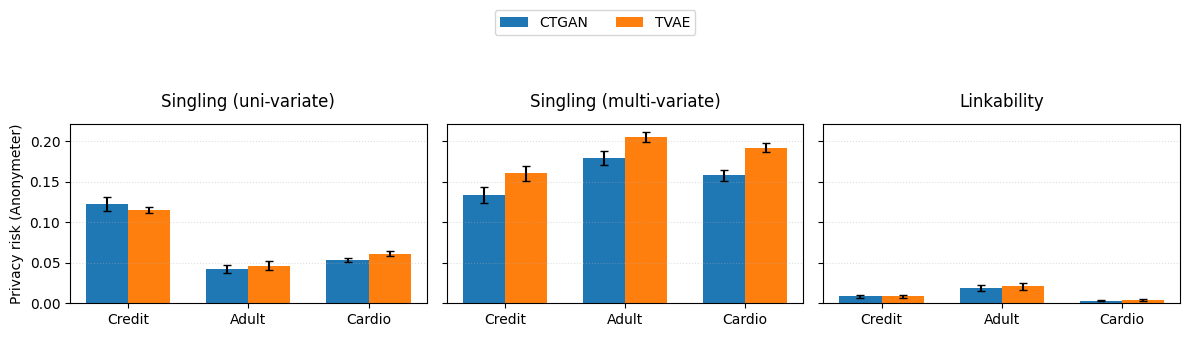

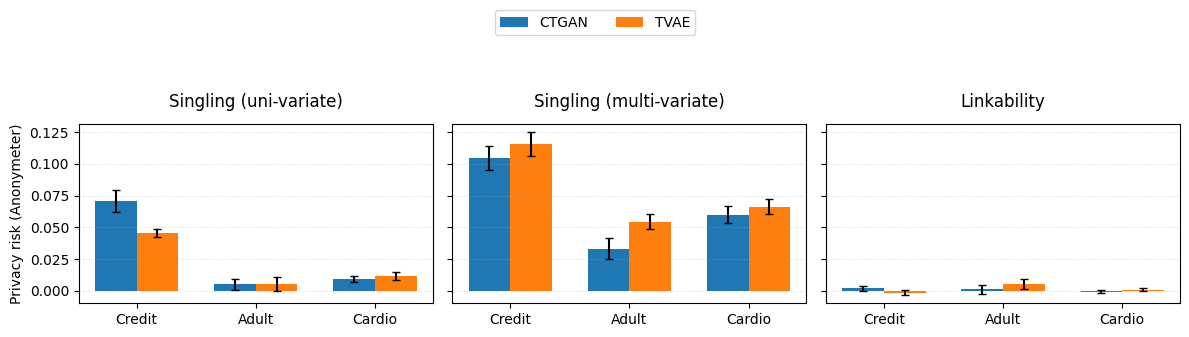

In [32]:
import matplotlib.pyplot as plt
import numpy as np

def plot_anonymeter_summary(df_summary, metric="mean_risk"):
    attacks = ["singling_univariate", "singling_multivariate", "linkability_attacks"]
    attack_labels = ["Singling (uni-variate)", "Singling (multi-variate)", "Linkability"]
    datasets = ["credit", "adult", "cardio"]
    generators = ["CTGAN", "TVAE"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

    plt.subplots_adjust(top=0.78, wspace=0.25)

    for i, (ax, attack, label) in enumerate(zip(axes, attacks, attack_labels)):
        sub = df_summary[df_summary["attack"] == attack]
        sub = sub.set_index(["dataset", "generator"])

        x = np.arange(len(datasets))
        width = 0.35

        means_ctgan, means_tvae = [], []
        stds_ctgan, stds_tvae = [], []

        for ds in datasets:

            if (ds, "CTGAN") in sub.index:
                row_c = sub.loc[(ds, "CTGAN")]
                means_ctgan.append(row_c[metric])
                stds_ctgan.append(row_c["std_risk"])
            else:
                means_ctgan.append(np.nan); stds_ctgan.append(0.0)

            if (ds, "TVAE") in sub.index:
                row_t = sub.loc[(ds, "TVAE")]
                means_tvae.append(row_t[metric])
                stds_tvae.append(row_t["std_risk"])
            else:
                means_tvae.append(np.nan); stds_tvae.append(0.0)

        # Only give labels on the FIRST subplot → avoids duplicated legend entries
        if i == 0:
            label_ctgan = "CTGAN"
            label_tvae = "TVAE"
        else:
            label_ctgan = None
            label_tvae = None

        ax.bar(x - width/2, means_ctgan, width, yerr=stds_ctgan,
               label=label_ctgan, capsize=3)
        ax.bar(x + width/2, means_tvae, width, yerr=stds_tvae,
               label=label_tvae, capsize=3)

        ax.set_xticks(x)
        ax.set_xticklabels([ds.capitalize() for ds in datasets])
        ax.set_title(label, pad=12)
        ax.grid(axis="y", linestyle=":", alpha=0.4)

    axes[0].set_ylabel("Privacy risk (Anonymeter)")

    fig.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.13))
    fig.tight_layout(rect=[0, 0, 1, 0.88])

    return fig


# Use mean_risk (privacy_risk_original) as the main metric
fig_risk = plot_anonymeter_summary(summary, metric="mean_risk")

# If you want to emphasize "extra risk over control":
fig_excess = plot_anonymeter_summary(summary, metric="mean_excess")


In [34]:
aia = {}

with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/credit_ctgan_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    aia['credit_ctgan_trtr'] = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/credit_ctgan_eps_none_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    aia['credit_ctgan_tstr'] = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/credit_tvae_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    aia['credit_tvae_trtr'] = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/credit_tvae_eps_none_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    aia['credit_tvae_tstr'] = pickle.load(file)


# with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/adult/adult_ctgan_attributes_real_models.pkl', 'rb') as file:
#     # Deserialize the object from the file
#     aia['adult_ctgan_trtr'] = pickle.load(file)

with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/adult_ctgan_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    aia['adult_ctgan_trtr'] = pickle.load(file)    
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/adult_ctgan_eps_none_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    aia['adult_ctgan_tstr'] = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/adult_tvae_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    aia['adult_tvae_trtr'] = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/adult_tvae_eps_none_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    aia['adult_tvae_tstr'] = pickle.load(file)


with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/cardio_ctgan_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    aia['cardio_ctgan_trtr'] = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/cardio_ctgan_eps_none_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    aia['cardio_ctgan_tstr'] = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/cardio_tvae_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    aia['cardio_tvae_trtr'] = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/cardio_tvae_eps_none_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    aia['cardio_tvae_tstr'] = pickle.load(file)

In [ ]:
notebooks/scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/adult/adult_ctgan_attributes_real_models.pkl

In [ ]:
np.array(dict_results_credit['credit CTGAN']['resemblance_evaluation_results']['categorical_univariate']['jensen_shanon_data_mean']).mean()

for key, result in dict_results_credit.items() :
    mean = np.array(result['resemblance_evaluation_results']['categorical_multivariate']['cramer_real']).mean()
    print(f"{key} : {mean}")

credit CTGAN : 0.31932047628733473
credit TVAE : 0.31932047628733473


In [ ]:
print('tvae : ', get_mode_collapse(df_real_credit_card_train, credit_tvae['generation_results']['synthetic_data'], cat_list_credit_card))
print('ctgan : ', get_mode_collapse(df_real_credit_card_train, credit_ctgan['generation_results']['synthetic_data'], cat_list_credit_card))
print('tvae 1 : ', get_mode_collapse(df_real_credit_card_train, credit_tvae_1['generation_results']['synthetic_data'], cat_list_credit_card))
print('ctgan 2 : ',get_mode_collapse(df_real_credit_card_train, credit_ctgan_1['generation_results']['synthetic_data'], cat_list_credit_card))


In [7]:
def print_epsilon(dict_results) :
    for key, item in dict_results.items() :
        print(f"{key} :", item['privacy_evaluation_results']['epsilon'])

In [8]:
def print_share(dict_results) :
    for key, item in dict_results.items() :
        print(f"{key} :", item['privacy_evaluation_results']['share'])

In [9]:
def print_synthetic_prediction(dict_results) :
    for key, item in dict_results.items() :
        print(f"{key} :", item['privacy_evaluation_results']['attribute_synthetic_prediction'])

In [21]:
import numpy as np
def print_singling_univariate(dict_results) :
    for key, item in dict_results.items() :
        mean = np.array([privacy['singling_univariate'].specific_privacy for row_number, privacy in item['privacy_anonymeter_results'].items()]).mean()
        std = np.array([privacy['singling_univariate'].specific_privacy for row_number, privacy in item['privacy_anonymeter_results'].items()]).std()
        print(f"{key} : {mean} +- {std}")

In [22]:
import numpy as np
def print_singling_multivariate(dict_results) :
    for key, item in dict_results.items() :
        mean = np.array([privacy['singling_multivariate'].specific_privacy for row_number, privacy in item['privacy_anonymeter_results'].items()]).mean()
        std = np.array([privacy['singling_multivariate'].specific_privacy for row_number, privacy in item['privacy_anonymeter_results'].items()]).std()
        print(f"{key} : {mean} +- {std}")

In [23]:
def print_linkability_attacks(dict_results) :
    for key, item in dict_results.items() :
        mean = np.array([privacy['linkability_attacks'].specific_privacy for row_number, privacy in item['privacy_anonymeter_results'].items()]).mean()
        std = np.array([privacy['linkability_attacks'].specific_privacy for row_number, privacy in item['privacy_anonymeter_results'].items()]).std()
        print(f"{key} : {mean} +- {std}")

In [20]:
print_epsilon(dict_results_credit)

credit CTGAN : 0.30233333333333334
credit CTGAN 0.3 : 0.2999583333333333
credit CTGAN 0.25 : 0.24995833333333334
credit CTGAN 0.2 : 0.19995833333333332
credit CTGAN 0.15 : 0.14995833333333333
credit CTGAN 0.1 : 0.09995833333333333
credit CTGAN 0.05 : 0.049958333333333334
credit CTGAN 0.01 : 0.009958333333333333
credit TVAE : 0.43141666666666667
credit TVAE 03 : 0.2999583333333333
credit TVAE 025 : 0.24995833333333334
credit TVAE 02 : 0.19995833333333332
credit TVAE 015 : 0.14995833333333333
credit TVAE 01 : 0.09995833333333333
credit TVAE 005 : 0.049958333333333334
credit TVAE 001 : 0.009958333333333333


In [21]:
print_share(dict_results_credit)

credit CTGAN : 38.91747774275223
credit CTGAN 0.3 : 38.93928683559891
credit CTGAN 0.25 : 39.142602663697815
credit CTGAN 0.2 : 39.33385215091351
credit CTGAN 0.15 : 39.79076069524305
credit CTGAN 0.1 : 40.642221458229606
credit CTGAN 0.05 : 42.29809490362932
credit CTGAN 0.01 : 43.590722479133994
credit TVAE : 37.09955128561171
credit TVAE 03 : 37.77607033609996
credit TVAE 025 : 38.23196068603469
credit TVAE 02 : 38.89476840262738
credit TVAE 015 : 39.83835558863458
credit TVAE 01 : 41.31105886029281
credit TVAE 005 : 43.564483531276565
credit TVAE 001 : 44.87897333714447


In [15]:
print_singling_univariate(dict_results_credit) 

credit CTGAN : 0.0727469954349668
credit TVAE : 0.0491622315182914


In [24]:
print_singling_multivariate(dict_results_credit) 

credit CTGAN : 0.10810962493035252 +- 0.008866270345256107
credit TVAE : 0.12126500532953118 +- 0.0101557372941661


In [25]:
print_linkability_attacks(dict_results_credit)

credit CTGAN : 0.002158145890587018 +- 0.0021967944968439537
credit TVAE : 0.00010055704937988849 +- 0.00030167114813966546


In [26]:
credit_resemblance_report.get_categorical_univariate_report()

NameError: name 'credit_resemblance_report' is not defined

In [31]:
credit_resemblance_report.get_numerical_univariate_report()

In [34]:
credit_resemblance_report.get_numerical_multivariate_report()

Accordion(children=(VBox(children=(Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x05\xdc\x00\x00\x…

In [35]:
credit_resemblance_report.get_categorical_multivariate_report()

Accordion(children=(VBox(children=(Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x05\xdc\x00\x00\x…

In [37]:
credit_utility_report.get_report()

Accordion(children=(VBox(children=(VBox(children=(Label(value='Accuracy Means:'), HTML(value='<table border="1…

In [36]:
credit_privacy_anonymeter_report.get_report()

KeyError: 'singling_univariate'

In [29]:
credit_privacy_report.get_report()

### Adult

In [10]:
# print(get_mode_collapse(df_real_adult_train, adult_ctgan['generation_results']['synthetic_data'], cat_list_adult))
print(get_mode_collapse(df_real_adult_train, adult_tvae['generation_results']['synthetic_data'], cat_list_adult))
# print(get_mode_collapse(df_real_adult_train, adult_ctgan_1['generation_results']['synthetic_data'], cat_list_adult))
# print(get_mode_collapse(df_real_adult_train, adult_tvae_1['generation_results']['synthetic_data'], cat_list_adult))

{'native-country': [' Holand-Netherlands']}


In [84]:
js = get_jsdivergence_result(dict_results_adult)
cohen = get_cohen_result(dict_results_adult)

(<Figure size 400x400 with 2 Axes>,
 <Axes: title={'center': "Credit (numeric) — |Cohen's d| per feature"}, xlabel='Model', ylabel='Feature'>)

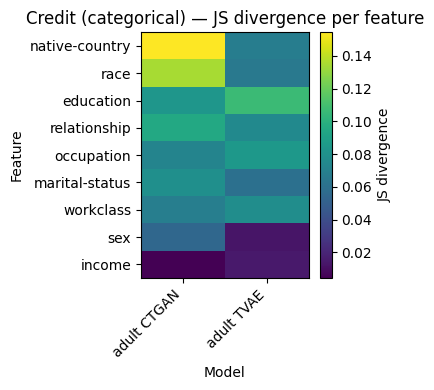

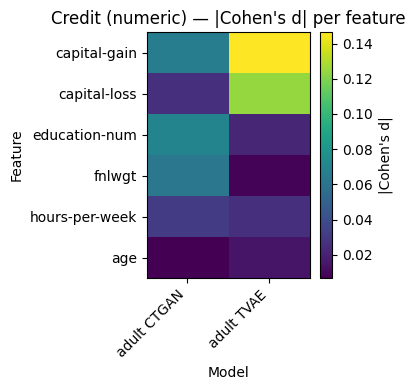

In [85]:
plot_per_feature_heatmap(
    js,
    metric_name="JS divergence",
    dataset_name="Credit (categorical)"
)
plot_per_feature_heatmap(
    cohen,
    metric_name="|Cohen's d|",
    dataset_name="Credit (numeric)"
)

### Cardio

In [11]:
print(get_mode_collapse(df_real_cardio_train, cardio_ctgan['generation_results']['synthetic_data'], cat_list_cardio))
print(get_mode_collapse(df_real_cardio_train, cardio_tvae['generation_results']['synthetic_data'], cat_list_cardio))
# print(get_mode_collapse(df_real_cardio_train, cardio_ctgan_1['generation_results']['synthetic_data'], cat_list_cardio))
# print(get_mode_collapse(df_real_cardio_train, cardio_tvae_1['generation_results']['synthetic_data'], cat_list_cardio))

{}
{}


In [88]:
js = get_jsdivergence_result(dict_results_cardio)
cohen = get_cohen_result(dict_results_cardio)

(<Figure size 400x400 with 2 Axes>,
 <Axes: title={'center': "Credit (numeric) — |Cohen's d| per feature"}, xlabel='Model', ylabel='Feature'>)

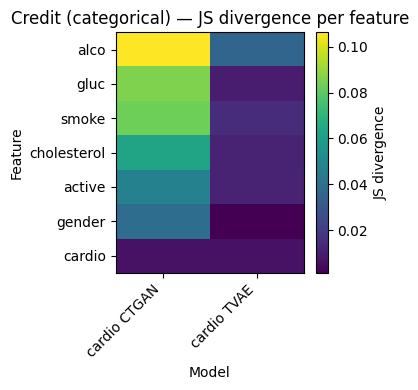

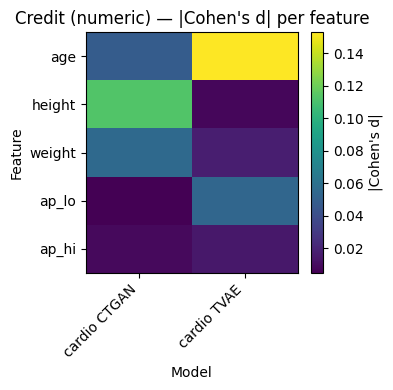

In [89]:
plot_per_feature_heatmap(
    js,
    metric_name="JS divergence",
    dataset_name="Credit (categorical)"
)
plot_per_feature_heatmap(
    cohen,
    metric_name="|Cohen's d|",
    dataset_name="Credit (numeric)"
)

In [23]:
adult_tvae_1['privacy_evaluation_results']


{'jensen_shanon_categorical':                 KL_divergence_tests  JS_divergence
 workclass                  0.023544       0.088156
 education                  0.034989       0.109201
 marital-status             0.003845       0.036633
 occupation                 0.016329       0.076535
 relationship               0.008997       0.055732
 race                       0.007520       0.053682
 sex                        0.002072       0.027217
 native-country                  inf       0.089946
 income                     0.000165       0.007736,
 'jensen_shanon_numerical':                 KL_divergence_tests  JS_divergence  cohen_s_d
 age                        0.008220       0.053521   0.040866
 fnlwgt                     0.007254       0.049918   0.011581
 education-num              0.017554       0.077938   0.088179
 capital-gain               1.988422       0.569093   0.131510
 capital-loss               0.049719       0.110845   0.061456
 hours-per-week             0.029715       0.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

real = df_real_adult_train
ctgan = adult_ctgan["generation_results"]['synthetic_data']
tvae = adult_tvae["generation_results"]['synthetic_data']


# Standardize features (important for distance-based methods)
scaler = StandardScaler()
X_real  = scaler.fit_transform(real[num_list_adult])
X_ctgan = scaler.transform(ctgan[num_list_adult])
X_tvae  = scaler.transform(tvae[num_list_adult])

k = 20  # size of local neighborhood
knn = NearestNeighbors(n_neighbors=k)
knn.fit(X_real)

# Distances from each point to its k nearest REAL neighbors
dist_real, _  = knn.kneighbors(X_real)
dist_ctgan, _ = knn.kneighbors(X_ctgan)
dist_tvae, _  = knn.kneighbors(X_tvae)

# Density proxy: inverse of mean distance to neighbors
eps = 1e-8
dens_real  = 1.0 / (dist_real.mean(axis=1)  + eps)
dens_ctgan = 1.0 / (dist_ctgan.mean(axis=1) + eps)
dens_tvae  = 1.0 / (dist_tvae.mean(axis=1)  + eps)

print("Mean local density adult :")
print("  Real :", dens_real.mean())
print("  CTGAN:", dens_ctgan.mean())
print("  TVAE :", dens_tvae.mean())

print("\nVariance of local density adult :")
print("  Real :", dens_real.var())
print("  CTGAN:", dens_ctgan.var())
print("  TVAE :", dens_tvae.var())


Mean local density adult :
  Real : 6.141592768955715
  CTGAN: 4.837146089351664
  TVAE : 4.935835908137321

Variance of local density adult :
  Real : 27.375968500753963
  CTGAN: 18.040534030869576
  TVAE : 18.57362815152039


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

real = df_real_credit_card_train
ctgan = credit_ctgan["generation_results"]['synthetic_data']
tvae = credit_tvae["generation_results"]['synthetic_data']


# Standardize features (important for distance-based methods)
scaler = StandardScaler()
X_real  = scaler.fit_transform(real[num_list_credit_card])
X_ctgan = scaler.transform(ctgan[num_list_credit_card])
X_tvae  = scaler.transform(tvae[num_list_credit_card])

k = 20  # size of local neighborhood
knn = NearestNeighbors(n_neighbors=k)
knn.fit(X_real)

# Distances from each point to its k nearest REAL neighbors
dist_real, _  = knn.kneighbors(X_real)
dist_ctgan, _ = knn.kneighbors(X_ctgan)
dist_tvae, _  = knn.kneighbors(X_tvae)

# Density proxy: inverse of mean distance to neighbors
eps = 1e-8
dens_real  = 1.0 / (dist_real.mean(axis=1)  + eps)
dens_ctgan = 1.0 / (dist_ctgan.mean(axis=1) + eps)
dens_tvae  = 1.0 / (dist_tvae.mean(axis=1)  + eps)

print("Mean local density credit:")
print("  Real :", dens_real.mean())
print("  CTGAN:", dens_ctgan.mean())
print("  TVAE :", dens_tvae.mean())

print("\nVariance of local density credit:")
print("  Real :", dens_real.var())
print("  CTGAN:", dens_ctgan.var())
print("  TVAE :", dens_tvae.var())


Mean local density credit:
  Real : 3.3254903575053043
  CTGAN: 2.3408907320836905
  TVAE : 2.122035374430374

Variance of local density credit:
  Real : 7.512653696535384
  CTGAN: 4.248422940614155
  TVAE : 2.398266867065753


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

real = df_real_cardio_train
ctgan = cardio_ctgan["generation_results"]['synthetic_data']
tvae = cardio_tvae["generation_results"]['synthetic_data']


# Standardize features (important for distance-based methods)
scaler = StandardScaler()
X_real  = scaler.fit_transform(real[num_list_cardio])
X_ctgan = scaler.transform(ctgan[num_list_cardio])
X_tvae  = scaler.transform(tvae[num_list_cardio])

k = 20  # size of local neighborhood
knn = NearestNeighbors(n_neighbors=k)
knn.fit(X_real)

# Distances from each point to its k nearest REAL neighbors
dist_real, _  = knn.kneighbors(X_real)
dist_ctgan, _ = knn.kneighbors(X_ctgan)
dist_tvae, _  = knn.kneighbors(X_tvae)

# Density proxy: inverse of mean distance to neighbors
eps = 1e-8
dens_real  = 1.0 / (dist_real.mean(axis=1)  + eps)
dens_ctgan = 1.0 / (dist_ctgan.mean(axis=1) + eps)
dens_tvae  = 1.0 / (dist_tvae.mean(axis=1)  + eps)

print("Mean local density cardio :")
print("  Real :", dens_real.mean())
print("  CTGAN:", dens_ctgan.mean())
print("  TVAE :", dens_tvae.mean())

print("\nVariance of local density cardio:")
print("  Real :", dens_real.var())
print("  CTGAN:", dens_ctgan.var())
print("  TVAE :", dens_tvae.var())


Mean local density cardio :
  Real : 7.551533282298709
  CTGAN: 6.20541060002577
  TVAE : 6.2928299804304055

Variance of local density cardio:
  Real : 30.6971382712536
  CTGAN: 6.26360428683318
  TVAE : 6.238012896340937


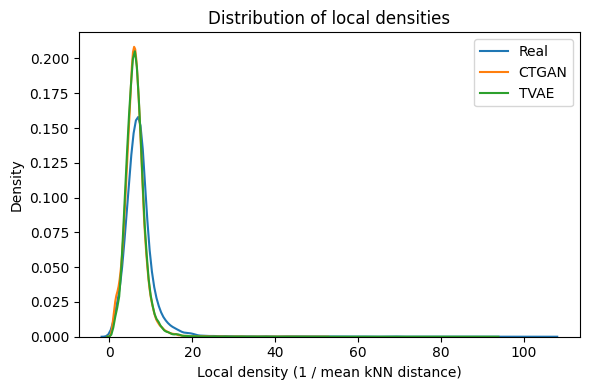

In [14]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.kdeplot(dens_real, label="Real")
sns.kdeplot(dens_ctgan, label="CTGAN")
sns.kdeplot(dens_tvae, label="TVAE")
plt.xlabel("Local density (1 / mean kNN distance)")
plt.title("Distribution of local densities")
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
low_quantile = np.quantile(dens_real, 0.05)  # bottom 5% densest outliers

print("Fraction of points below real 5% density threshold:")
print("  Real :", (dens_real  < low_quantile).mean())
print("  CTGAN:", (dens_ctgan < low_quantile).mean())
print("  TVAE :", (dens_tvae < low_quantile).mean())


Fraction of points below real 5% density threshold:
  Real : 0.05
  CTGAN: 0.0646734693877551
  TVAE : 0.04314285714285714


In [20]:
corr_real  = real[num_list_cardio].corr()
corr_ctgan = ctgan[num_list_cardio].corr()
corr_tvae  = tvae[num_list_cardio].corr()

# How similar are correlation matrices?
diff_ctgan = (corr_real - corr_ctgan).abs().mean().mean()
diff_tvae  = (corr_real - corr_tvae).abs().mean().mean()
print("Mean absolute correlation diff:")
print("  CTGAN:", diff_ctgan)
print("  TVAE :", diff_tvae)


Mean absolute correlation diff:
  CTGAN: 0.07135392871731444
  TVAE : 0.03158232016072619


In [ ]:
subset = num_cols[:4]

real_sub = real[subset].copy()
real_sub["source"] = "Real"

ctgan_sub = ctgan[subset].copy()
ctgan_sub["source"] = "CTGAN"

tvae_sub = tvae[subset].copy()
tvae_sub["source"] = "TVAE"

df_all = pd.concat([real_sub, ctgan_sub, tvae_sub], ignore_index=True)

sns.pairplot(df_all, vars=subset, hue="source", plot_kws={"alpha":0.4, "s":10})
plt.show()


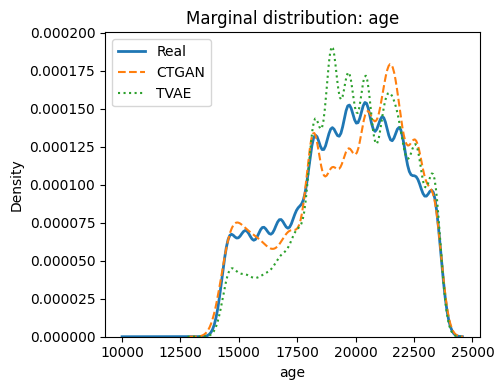

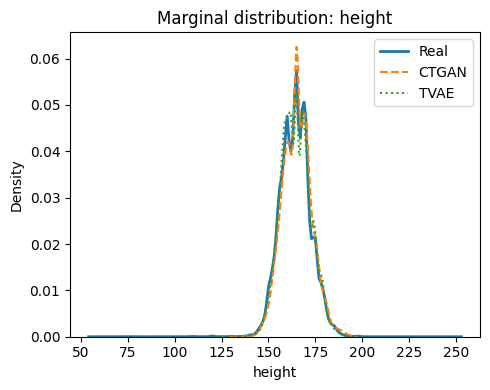

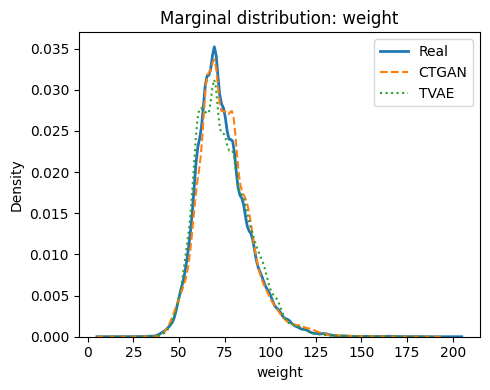

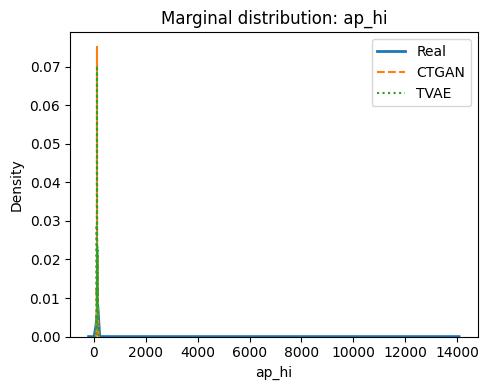

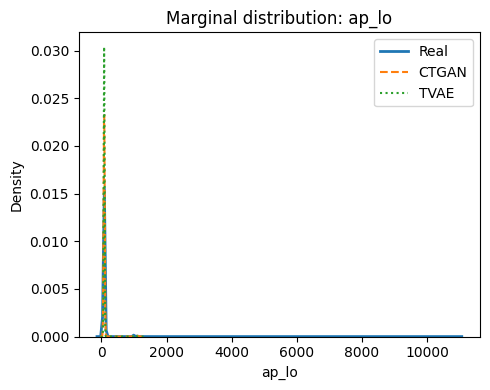

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_list_cardio:
    plt.figure(figsize=(5, 4))
    sns.kdeplot(real[col], label="Real", linewidth=2)
    sns.kdeplot(ctgan[col], label="CTGAN", linestyle="--")
    sns.kdeplot(tvae[col], label="TVAE", linestyle=":")
    plt.title(f"Marginal distribution: {col}")
    plt.legend()
    plt.tight_layout()
    plt.show()
